In [5]:
import octis
print("OCTIS version:", octis.__version__)

OCTIS version: 1.14.0


In [1]:
!pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn gensim PySastrawi octis -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
import umap
from hdbscan import HDBSCAN
from sklearn.cluster import Birch, KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              silhouette_samples)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel

from octis.evaluation_metrics.coherence_metrics import Coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from collections import Counter

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

print("✓ Semua library berhasil diimport!")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✓ Semua library berhasil diimport!


In [ ]:
# ── Load Data ─────────────────────────────────────────────────────
df_no_stem = pd.read_csv(r'C:\Users\Admin\Downloads\data_clean_no_stemming (3).csv')
docs       = df_no_stem['clean_text'].dropna().tolist()

print(f"✓ Data loaded   : {len(docs):,} dokumen")
print(f"\n📝 Contoh dokumen:")
for i, d in enumerate(docs[:3], 1):
    print(f"   {i}. {d[:100]}")

# ── Embedding ─────────────────────────────────────────────────────
print("\n🔄 Loading IndoBERT embedding model...")
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")
print("✓ Model loaded")

print("\n🔄 Generating embeddings...")
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

np.save("embeddings_no_stemming.npy", embeddings)
print(f"\n✓ Embeddings shape : {embeddings.shape}")
print(f"✓ Disimpan ke      : embeddings_no_stemming.npy")

✓ Data loaded   : 1,699 dokumen

📝 Contoh dokumen:
   1. mau masuk beranda selalu loading
   2. aplikasi rumah sakit terbaik
   3. aplikasi lengkap fitur andalan informatif

🔄 Loading IndoBERT embedding model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1759.90it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded

🔄 Generating embeddings...


Batches: 100%|██████████| 54/54 [00:11<00:00,  4.69it/s]


✓ Embeddings shape : (1699, 384)
✓ Disimpan ke      : embeddings_no_stemming.npy


In [3]:
print("🔄 Running UMAP...")

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
    transform_seed=42
)

umap_embeddings = umap_model.fit_transform(embeddings)
np.save("umap_embeddings_no_stemming.npy", umap_embeddings)

print(f"✓ UMAP output shape : {umap_embeddings.shape}")
print(f"✓ Disimpan ke       : umap_embeddings_no_stemming.npy")

🔄 Running UMAP...
✓ UMAP output shape : (1699, 5)
✓ Disimpan ke       : umap_embeddings_no_stemming.npy


ANALISIS SILHOUETTE & DBI — BIRCH & KMeans

      k   Sil-KMeans   DBI-KMeans    Sil-BIRCH    DBI-BIRCH
   ──────────────────────────────────────────────────────
      2       0.5221       0.7572       0.4772       0.7862
      3       0.5129       0.7189       0.5046       0.7246
      4       0.5635       0.5893       0.5533       0.5978
      5       0.5057       0.6949       0.4874       0.6967
      6       0.4905       0.7442       0.4767       0.7312
      7       0.4625       0.8639       0.4963       0.6659
      8       0.4196       0.9362       0.4600       0.7150
      9       0.4332       0.8789       0.4536       0.8133
     10       0.4058       0.9646       0.4167       0.9086
     11       0.3995       0.9741       0.3753       1.0161
     12       0.4058       0.9612       0.3866       0.9711
     13       0.4153       0.9261       0.3906       0.9477
     14       0.4126       0.9408       0.3931       0.9595
     15       0.4122       0.9291       0.3983       0.919

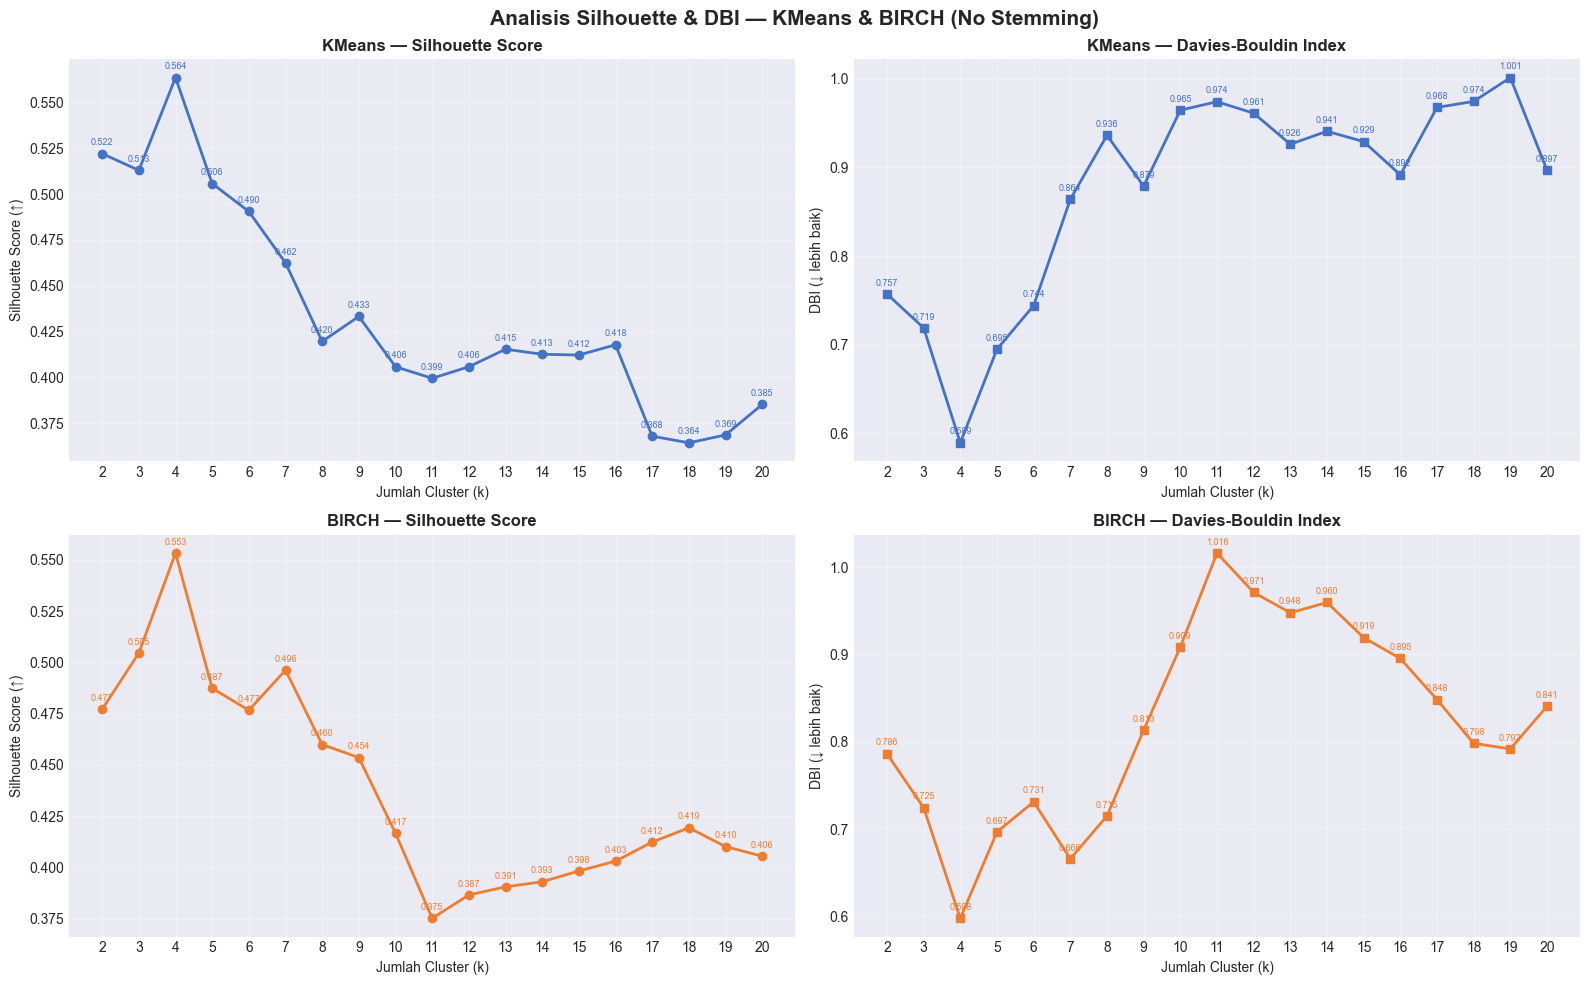

✓ Disimpan: k_analysis_line_chart.png

🔄 Menghitung silhouette & DBI per cluster...
  k= 2 | KMeans sil=0.5221 dbi=0.7572 | BIRCH sil=0.4772 dbi=0.7862
  k= 3 | KMeans sil=0.5129 dbi=0.7189 | BIRCH sil=0.5046 dbi=0.7246
  k= 4 | KMeans sil=0.5635 dbi=0.5893 | BIRCH sil=0.5533 dbi=0.5978
  k= 5 | KMeans sil=0.5057 dbi=0.6949 | BIRCH sil=0.4874 dbi=0.6967
  k= 6 | KMeans sil=0.4905 dbi=0.7442 | BIRCH sil=0.4767 dbi=0.7312
  k= 7 | KMeans sil=0.4625 dbi=0.8639 | BIRCH sil=0.4963 dbi=0.6659


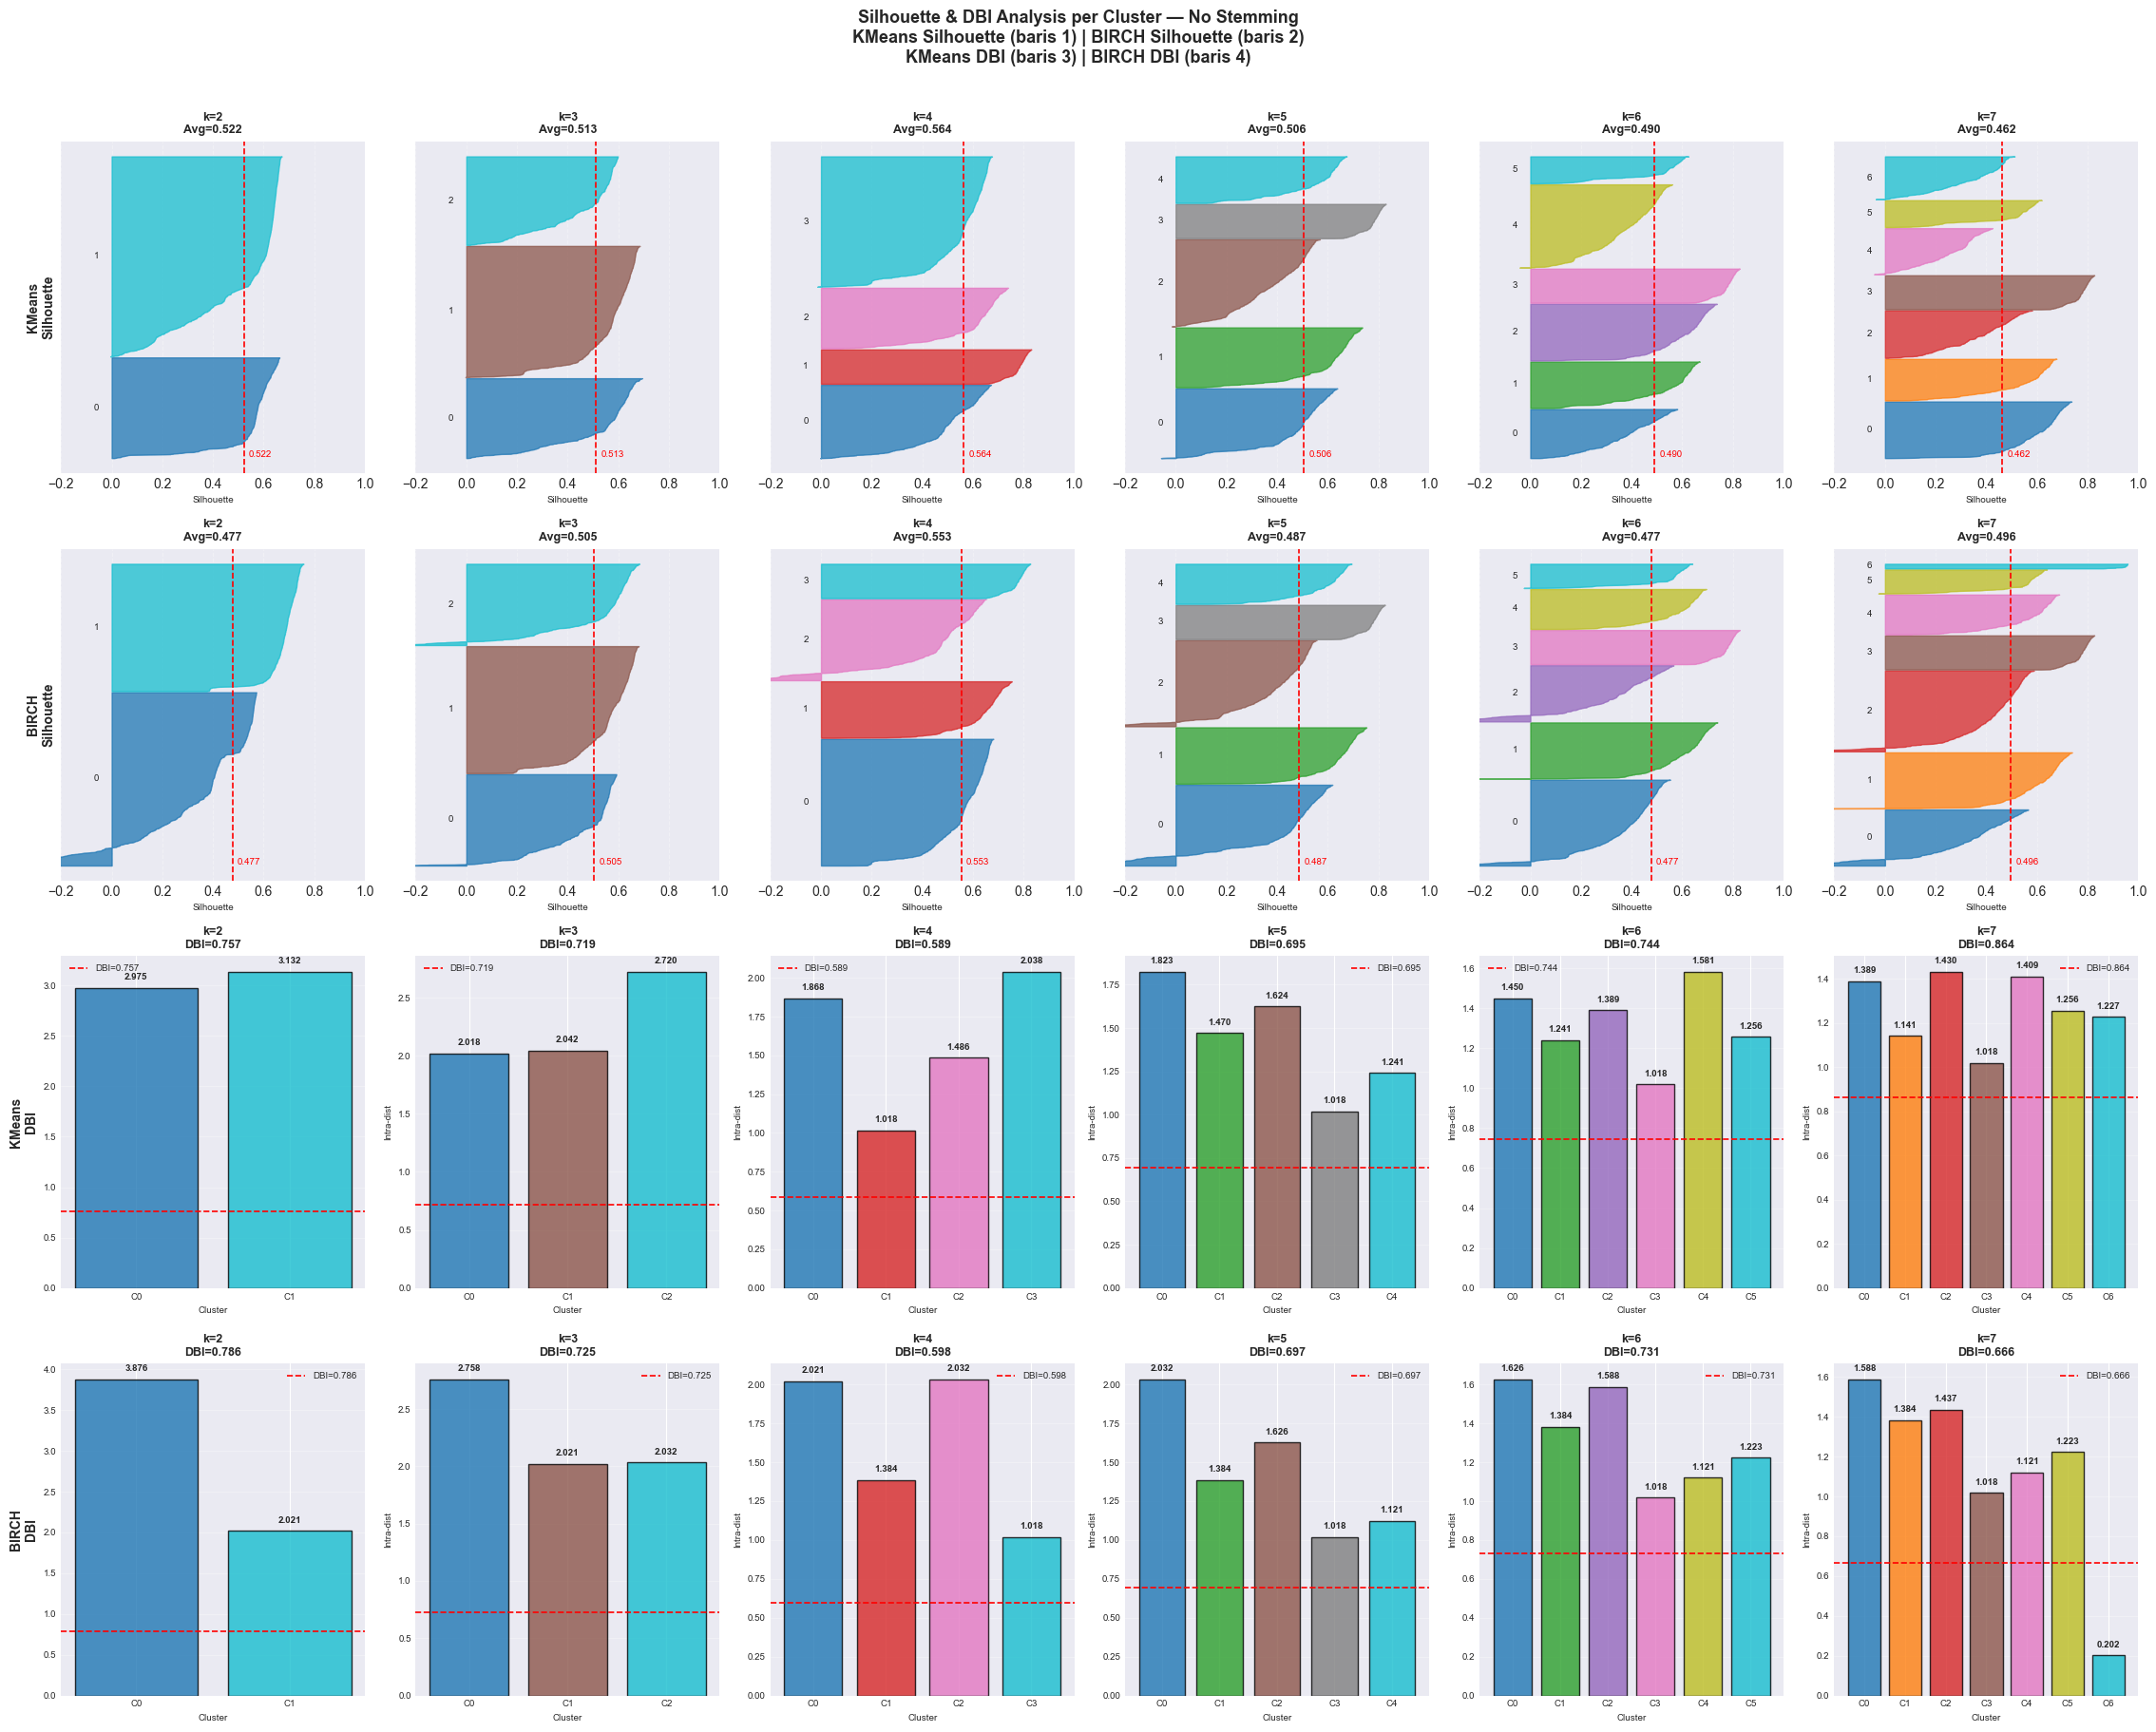


✓ Disimpan: silhouette_dbi_plot_per_cluster.png


In [4]:
print("="*70)
print("ANALISIS SILHOUETTE & DBI — BIRCH & KMeans")
print("="*70)

k_range    = range(2, 21)
sil_birch  = []
dbi_birch  = []
sil_kmeans = []
dbi_kmeans = []

print(f"\n   {'k':>4} {'Sil-KMeans':>12} {'DBI-KMeans':>12} "
      f"{'Sil-BIRCH':>12} {'DBI-BIRCH':>12}")
print("   " + "─"*54)

for k in k_range:
    km  = KMeans(n_clusters=k, n_init=10, random_state=42)
    lkm = km.fit_predict(umap_embeddings)
    skm = silhouette_score(umap_embeddings, lkm)
    dkm = davies_bouldin_score(umap_embeddings, lkm)
    sil_kmeans.append(skm)
    dbi_kmeans.append(dkm)

    br  = Birch(threshold=0.5, n_clusters=k, branching_factor=50)
    lbr = br.fit_predict(umap_embeddings)
    sbr = silhouette_score(umap_embeddings, lbr)
    dbr = davies_bouldin_score(umap_embeddings, lbr)
    sil_birch.append(sbr)
    dbi_birch.append(dbr)

    print(f"   {k:>4} {skm:>12.4f} {dkm:>12.4f} "
          f"{sbr:>12.4f} {dbr:>12.4f}")

k_list = list(k_range)

# ── Line Chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analisis Silhouette & DBI — KMeans & BIRCH (No Stemming)',
             fontsize=15, fontweight='bold')

plot_configs = [
    (axes[0,0], sil_kmeans, '#4472C4', 'KMeans — Silhouette Score',        'Silhouette Score (↑)'),
    (axes[0,1], dbi_kmeans, '#4472C4', 'KMeans — Davies-Bouldin Index',    'DBI (↓ lebih baik)'),
    (axes[1,0], sil_birch,  '#ED7D31', 'BIRCH — Silhouette Score',         'Silhouette Score (↑)'),
    (axes[1,1], dbi_birch,  '#ED7D31', 'BIRCH — Davies-Bouldin Index',     'DBI (↓ lebih baik)'),
]

for ax, data, color, title, ylabel in plot_configs:
    marker = 'o' if 'Silhouette' in title else 's'
    ax.plot(k_list, data, f'{marker}-', color=color, linewidth=2, markersize=6)
    for k, v in zip(k_list, data):
        ax.annotate(f'{v:.3f}', (k, v), textcoords="offset points",
                    xytext=(0, 6), ha='center', fontsize=6.5, color=color)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('Jumlah Cluster (k)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(k_list)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('k_analysis_line_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: k_analysis_line_chart.png")

# ── Silhouette Plot per Cluster ───────────────────────────────────
k_values = list(range(2, 8))

def plot_silhouette(ax, embeddings, labels, k, avg_score):
    n_clusters      = len(set(labels))
    silhouette_vals = silhouette_samples(embeddings, labels)
    y_lower         = 10
    palette         = cm.get_cmap('tab10', n_clusters)

    for i in range(n_clusters):
        cluster_vals = np.sort(silhouette_vals[labels == i])
        size_i       = cluster_vals.shape[0]
        y_upper      = y_lower + size_i
        color        = palette(i / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                         facecolor=color, edgecolor=color, alpha=0.75)
        ax.text(-0.05, y_lower + 0.5*size_i, str(i),
                fontsize=7, va='center', ha='right')
        y_lower = y_upper + 5

    ax.axvline(avg_score, color='red', linestyle='--', linewidth=1.2)
    ax.text(avg_score+0.02, 5, f'{avg_score:.3f}',
            color='red', fontsize=7, va='bottom')
    ax.set_title(f"k={k}\nAvg={avg_score:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlim([-0.2, 1.0])
    ax.set_xlabel('Silhouette', fontsize=7)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3, linestyle='--')

def plot_dbi_bar(ax, embeddings, labels, k, dbi_score):
    from sklearn.metrics import pairwise_distances
    unique_labels = sorted(set(labels))
    n_clusters    = len(unique_labels)
    palette       = cm.get_cmap('tab10', n_clusters)
    intra_dists   = []

    for label in unique_labels:
        pts = embeddings[labels == label]
        if len(pts) > 1:
            dists = pairwise_distances(pts, metric='euclidean')
            intra = dists[np.triu_indices_from(dists, k=1)].mean()
        else:
            intra = 0.0
        intra_dists.append(intra)

    colors = [palette(i / n_clusters) for i in range(n_clusters)]
    bars   = ax.bar([f'C{i}' for i in unique_labels], intra_dists,
                    color=colors, edgecolor='black', alpha=0.8)

    for bar, val in zip(bars, intra_dists):
        ax.text(bar.get_x() + bar.get_width()/2.,
                bar.get_height() + max(intra_dists)*0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold')

    ax.axhline(dbi_score, color='red', linestyle='--',
               linewidth=1.2, label=f'DBI={dbi_score:.3f}')
    ax.legend(fontsize=7)
    ax.set_title(f"k={k}\nDBI={dbi_score:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Cluster', fontsize=7)
    ax.set_ylabel('Intra-dist', fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(labelsize=7)

n_cols = len(k_values)
fig, axes = plt.subplots(4, n_cols, figsize=(n_cols*3.8, 18))
fig.suptitle(
    "Silhouette & DBI Analysis per Cluster — No Stemming\n"
    "KMeans Silhouette (baris 1) | BIRCH Silhouette (baris 2)\n"
    "KMeans DBI (baris 3) | BIRCH DBI (baris 4)",
    fontsize=13, fontweight='bold', y=1.01
)

print("\n🔄 Menghitung silhouette & DBI per cluster...")
for col, k in enumerate(k_values):
    km        = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(umap_embeddings)
    km_sil    = silhouette_score(umap_embeddings, km_labels)
    km_dbi    = davies_bouldin_score(umap_embeddings, km_labels)

    br        = Birch(threshold=0.5, n_clusters=k, branching_factor=50)
    br_labels = br.fit_predict(umap_embeddings)
    br_sil    = silhouette_score(umap_embeddings, br_labels)
    br_dbi    = davies_bouldin_score(umap_embeddings, br_labels)

    plot_silhouette(axes[0, col], umap_embeddings, km_labels, k, km_sil)
    plot_silhouette(axes[1, col], umap_embeddings, br_labels, k, br_sil)
    plot_dbi_bar(axes[2, col], umap_embeddings, km_labels, k, km_dbi)
    plot_dbi_bar(axes[3, col], umap_embeddings, br_labels, k, br_dbi)

    print(f"  k={k:2d} | KMeans sil={km_sil:.4f} dbi={km_dbi:.4f} "
          f"| BIRCH sil={br_sil:.4f} dbi={br_dbi:.4f}")

row_labels = ["KMeans\nSilhouette","BIRCH\nSilhouette",
              "KMeans\nDBI","BIRCH\nDBI"]
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('silhouette_dbi_plot_per_cluster.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✓ Disimpan: silhouette_dbi_plot_per_cluster.png")

In [5]:
# ── Isi setelah melihat visualisasi ──────────────────────────────
k_opt_kmeans = 3   # ← ganti sesuai pilihanmu
k_opt_birch  = 3   # ← ganti sesuai pilihanmu

print(f"{'='*50}")
print(f"✅ K Optimal yang Dipilih (No Stemming)")
print(f"{'='*50}")
print(f"   KMeans → k = {k_opt_kmeans}  "
      f"(Sil: {sil_kmeans[k_opt_kmeans-2]:.4f}, "
      f"DBI: {dbi_kmeans[k_opt_kmeans-2]:.4f})")
print(f"   BIRCH  → k = {k_opt_birch}  "
      f"(Sil: {sil_birch[k_opt_birch-2]:.4f}, "
      f"DBI: {dbi_birch[k_opt_birch-2]:.4f})")

✅ K Optimal yang Dipilih (No Stemming)
   KMeans → k = 3  (Sil: 0.5129, DBI: 0.7189)
   BIRCH  → k = 3  (Sil: 0.5046, DBI: 0.7246)


In [6]:
print("="*70)
print("INISIALISASI CLUSTERING MODELS & VECTORIZER")
print("="*70)

# ── Clustering Models ─────────────────────────────────────────────
hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=3,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon=0.4,
    prediction_data=True
)

birch_model  = Birch(
    n_clusters=k_opt_birch,
    threshold=0.5,
    branching_factor=50
)

kmeans_model = KMeans(
    n_clusters=k_opt_kmeans,
    n_init=10,
    random_state=42
)

# ── Stopwords ─────────────────────────────────────────────────────
factory_sw    = StopWordRemoverFactory()
stopwords_id  = factory_sw.get_stop_words()

additional_sw = [
    'yg','nya','dgn','utk','ttg','yaa','aja','nih','sih','deh',
    'dong','kok','lah','hehe','wkwk','haha','u','x','tp','sy','dn','ok',
    'mysiloam','siloam','rs','my','the','so','this','that','and','or',
    'but','really','very','all','is','di','ke','dan',
    'semoga','selalu','sukses','terus','semakin',
    'terima','kasih','terimakasih','trimakasih',
    'aplikasi','apk','app','pelayanan','layanan',
]
all_stopwords = set(stopwords_id + additional_sw)

# ── Vectorizer ────────────────────────────────────────────────────
vectorizer_density = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=list(all_stopwords),
    min_df=2,
    max_df=0.95
)

vectorizer_kmeans = CountVectorizer(
    ngram_range=(1, 2),
    stop_words=list(all_stopwords),
    min_df=1,
    max_df=1.0
)

ctfidf_model         = ClassTfidfTransformer(reduce_frequent_words=True)
representation_model = MaximalMarginalRelevance(diversity=0.6, top_n_words=10)

print(f"✓ HDBSCAN  : min_cluster_size=20, min_samples=3")
print(f"✓ BIRCH    : n_clusters={k_opt_birch}")
print(f"✓ KMeans   : n_clusters={k_opt_kmeans}")
print(f"✓ Stopwords: {len(all_stopwords)} kata")

INISIALISASI CLUSTERING MODELS & VECTORIZER
✓ HDBSCAN  : min_cluster_size=20, min_samples=3
✓ BIRCH    : n_clusters=3
✓ KMeans   : n_clusters=3
✓ Stopwords: 851 kata


In [7]:
print("="*70)
print("RUNNING BERTOPIC — 3 CLUSTERING MODELS")
print("="*70)

bertopic_models  = {}
bertopic_results = {}

cluster_configs = {
    "HDBSCAN": (hdbscan_model, vectorizer_density, representation_model, True),
    "BIRCH"  : (birch_model,   vectorizer_density, representation_model, False),
    "KMEANS" : (kmeans_model,  vectorizer_kmeans,  None,                 False),
}

for name, (cluster_model, vectorizer, repr_model, calc_prob) \
        in cluster_configs.items():

    print(f"\n{'─'*70}")
    print(f"📌 Running BERTopic + {name}")
    print(f"{'─'*70}")

    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=cluster_model,
        vectorizer_model=vectorizer,
        ctfidf_model=ctfidf_model,
        representation_model=repr_model,
        calculate_probabilities=calc_prob,
        verbose=True
    )

    topics, probs = topic_model.fit_transform(
        docs, embeddings=embeddings
    )

    info       = topic_model.get_topic_info()
    is_hdbscan = (name == "HDBSCAN")
    n_topics   = len(info[info.Topic != -1]) if is_hdbscan else len(info)
    noise_count = sum(t == -1 for t in topics) if is_hdbscan else 0
    noise_ratio = noise_count / len(topics) * 100 if is_hdbscan else 0.0

    print(f"\n  ✓ Selesai!")
    print(f"  🧩 Jumlah topik  : {n_topics}")
    print(f"  ⚠️  Noise docs    : {noise_count} ({noise_ratio:.1f}%)")
    print(f"\n  {'ID':>6} {'N Dok':>7}   Top Words")
    print(f"  {'─'*65}")

    for _, row in info.iterrows():
        if is_hdbscan and row['Topic'] == -1:
            continue
        words = topic_model.get_topic(row['Topic'])
        top   = ", ".join([w for w, _ in words[:7]]) if words else "-"
        print(f"  #{row['Topic']:<5}  {row['Count']:>7,}   {top}")

    bertopic_models[name]  = topic_model
    bertopic_results[name] = {
        "topics"     : topics,
        "probs"      : probs if is_hdbscan else None,
        "n_topics"   : n_topics,
        "noise_count": noise_count,
        "noise_ratio": noise_ratio,
        "topic_info" : info,
    }

print(f"\n{'='*70}")
print("✓ Semua model selesai!")
for name, res in bertopic_results.items():
    print(f"  {name:<10}: {res['n_topics']} topik, "
          f"noise: {res['noise_count']} ({res['noise_ratio']:.1f}%)")

2026-04-01 07:54:22,634 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


RUNNING BERTOPIC — 3 CLUSTERING MODELS

──────────────────────────────────────────────────────────────────────
📌 Running BERTopic + HDBSCAN
──────────────────────────────────────────────────────────────────────


2026-04-01 07:54:28,134 - BERTopic - Dimensionality - Completed ✓
2026-04-01 07:54:28,135 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-01 07:54:28,322 - BERTopic - Cluster - Completed ✓
2026-04-01 07:54:28,343 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 07:54:29,065 - BERTopic - Representation - Completed ✓
2026-04-01 07:54:29,125 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



  ✓ Selesai!
  🧩 Jumlah topik  : 5
  ⚠️  Noise docs    : 42 (2.5%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0        1,111   sakit, rumah sakit, jadwal, perawat, ramah, memudahkan, pendaftaran
  #1          293   mudah membantu, terbaik, rumit, bintang, menghemat waktu, efisien, cepat membantu
  #2          196   ramah, cepat, profesional, bagus ramah, pelayanannya bagus, puas, bersih
  #3           30   com, antri daftar, memudahkan memudahkan, programmer, membantu mempercepat, cek up, make
  #4           27   daftar vaksin, daftar bayar, positif, tolak, test, efektif efisien, regis ulang

──────────────────────────────────────────────────────────────────────
📌 Running BERTopic + BIRCH
──────────────────────────────────────────────────────────────────────


2026-04-01 07:54:34,071 - BERTopic - Dimensionality - Completed ✓
2026-04-01 07:54:34,072 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-01 07:54:34,118 - BERTopic - Cluster - Completed ✓
2026-04-01 07:54:34,122 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 07:54:34,462 - BERTopic - Representation - Completed ✓
2026-04-01 07:54:34,502 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm



  ✓ Selesai!
  🧩 Jumlah topik  : 3
  ⚠️  Noise docs    : 0 (0.0%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0          720   rumah sakit, jadwal, obat, vaksin, praktek, asuransi, pulang
  #1          518   profesional, ramah memuaskan, pelayanannya bagus, bersih, mudah membantu, fasilitas, pelayananya
  #2          461   update, booking, otp, email, login, wa, apps

──────────────────────────────────────────────────────────────────────
📌 Running BERTopic + KMEANS
──────────────────────────────────────────────────────────────────────


2026-04-01 07:54:39,438 - BERTopic - Dimensionality - Completed ✓
2026-04-01 07:54:39,440 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-01 07:54:39,602 - BERTopic - Cluster - Completed ✓
2026-04-01 07:54:39,607 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-01 07:54:39,677 - BERTopic - Representation - Completed ✓



  ✓ Selesai!
  🧩 Jumlah topik  : 3
  ⚠️  Noise docs    : 0 (0.0%)

      ID   N Dok   Top Words
  ─────────────────────────────────────────────────────────────────
  #0          744   dokter, sakit, rumah, rumah sakit, pasien, jam, janji
  #1          502   bagus, cepat, memuaskan, membantu, ramah, pelayanannya, mudah
  #2          453   mudah, aplikasinya, error, membantu, daftar, update, data

✓ Semua model selesai!
  HDBSCAN   : 5 topik, noise: 42 (2.5%)
  BIRCH     : 3 topik, noise: 0 (0.0%)
  KMEANS    : 3 topik, noise: 0 (0.0%)


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Gensim untuk C_V & U_MASS
from gensim.models.coherencemodel import CoherenceModel
import gensim.corpora as corpora

# OCTIS untuk NPMI & Topic Diversity
from octis.evaluation_metrics.coherence_metrics import Coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity

# BERTopic untuk Stability
from bertopic import BERTopic

print("✓ Semua library berhasil diimport!")
print("\n📦 Library:")
print("   Gensim → C_V, U_MASS")
print("   OCTIS  → NPMI, Topic Diversity")
print("   Numpy  → Perplexity")
print("   Manual → Stability (Jaccard)")

✓ Semua library berhasil diimport!

📦 Library:
   Gensim → C_V, U_MASS
   OCTIS  → NPMI, Topic Diversity
   Numpy  → Perplexity
   Manual → Stability (Jaccard)


In [9]:
print("="*70)
print("PERSIAPAN CORPUS & FORMAT OCTIS")
print("="*70)

# ── Corpus untuk Gensim & OCTIS ───────────────────────────────────
# Sama seperti dataset.get_corpus() di referensi
texts_tokenized = [str(doc).lower().split() for doc in docs]

# Untuk Gensim
dictionary = corpora.Dictionary(texts_tokenized)
dictionary.filter_extremes(no_below=3, no_above=0.90)

print(f"✓ Total dokumen    : {len(texts_tokenized):,}")
print(f"✓ Dictionary size  : {len(dictionary):,} kata")

# ── Konversi BERTopic → format output OCTIS ───────────────────────
# Sama seperti output = model.train_model(dataset) di referensi
def bertopic_to_octis(topic_model, top_n=10):
    """
    Konversi output BERTopic ke format OCTIS.
    Format: {"topics": [[kata1, kata2, ...], ...]}
    Referensi: output['topics'] dari OCTIS train_model()
    """
    info   = topic_model.get_topic_info()
    topics = []
    for _, row in info.iterrows():
        tid = row["Topic"]
        if tid == -1:
            continue
        words = topic_model.get_topic(tid)
        if words:
            topics.append([w for w, _ in words[:top_n]])
    return {"topics": topics}

print("✓ Fungsi bertopic_to_octis siap")

# ── Inisialisasi metrik OCTIS ─────────────────────────────────────
# Persis seperti referensi:
# npmi = Coherence(texts=dataset.get_corpus(), topk=10, measure='c_npmi')
# topic_diversity = TopicDiversity(topk=10)
npmi_metric      = Coherence(
    texts=texts_tokenized,   # ← ganti dataset.get_corpus()
    topk=10,
    measure='c_npmi'
)
diversity_metric = TopicDiversity(topk=10)

print("✓ OCTIS Coherence (NPMI)     → npmi_metric siap")
print("✓ OCTIS TopicDiversity       → diversity_metric siap")

# ── Verifikasi konversi ───────────────────────────────────────────
print("\n📝 Contoh format OCTIS output (HDBSCAN):")
sample = bertopic_to_octis(bertopic_models["HDBSCAN"], top_n=5)
for i, t in enumerate(sample["topics"][:3]):
    print(f"   Topik {i}: {t}")

PERSIAPAN CORPUS & FORMAT OCTIS
✓ Total dokumen    : 1,699
✓ Dictionary size  : 890 kata
✓ Fungsi bertopic_to_octis siap
✓ OCTIS Coherence (NPMI)     → npmi_metric siap
✓ OCTIS TopicDiversity       → diversity_metric siap

📝 Contoh format OCTIS output (HDBSCAN):
   Topik 0: ['sakit', 'rumah sakit', 'jadwal', 'perawat', 'ramah']
   Topik 1: ['mudah membantu', 'terbaik', 'rumit', 'bintang', 'menghemat waktu']
   Topik 2: ['ramah', 'cepat', 'profesional', 'bagus ramah', 'pelayanannya bagus']


In [10]:
# ── C_V & U_MASS via Gensim ───────────────────────────────────────
def compute_coherence_gensim(topic_model, metric="c_v", top_n=10):
    info         = topic_model.get_topic_info()
    topics_words = []
    for _, row in info.iterrows():
        tid = row["Topic"]
        if str(tid) == '-1':
            continue
        words = topic_model.get_topic(tid)
        tw    = [w for w, _ in (words or [])[:top_n*3]
                 if w in dictionary.token2id][:top_n]
        if len(tw) >= 2:
            topics_words.append(tw)
    if len(topics_words) < 2:
        return 0.0
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenized,
            dictionary=dictionary,
            coherence=metric,
            topn=top_n
        )
        return round(cm.get_coherence(), 4)
    except Exception as e:
        print(f"    ⚠️  {metric} error: {e}")
        return 0.0


# ── Stability via Jaccard ─────────────────────────────────────────
def jaccard_similarity(set1, set2):
    s1 = set(set1); s2 = set(set2)
    return len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0.0


def compute_stability(topic_model, docs, embeddings,
                      cluster_model, vectorizer,
                      repr_model, calc_prob,
                      n_runs=3, top_n=10):
    all_run_topics = []

    # Run 1 dari model existing
    base = []
    for _, row in topic_model.get_topic_info().iterrows():
        if row['Topic'] == -1: continue
        w = topic_model.get_topic(row['Topic'])
        if w: base.append([x for x, _ in w[:top_n]])
    all_run_topics.append(base)
    print(f"     Run 1/{n_runs} ✓ ({len(base)} topik)")

    # Run tambahan
    for run in range(n_runs - 1):
        print(f"     Run {run+2}/{n_runs}...", end=" ")
        try:
            tm_temp = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=cluster_model,
                vectorizer_model=vectorizer,
                ctfidf_model=ctfidf_model,
                representation_model=repr_model,
                calculate_probabilities=calc_prob,
                verbose=False
            )
            tm_temp.fit_transform(docs, embeddings=embeddings)
            run_topics = []
            for _, row in tm_temp.get_topic_info().iterrows():
                if row['Topic'] == -1: continue
                w = tm_temp.get_topic(row['Topic'])
                if w: run_topics.append([x for x, _ in w[:top_n]])
            all_run_topics.append(run_topics)
            print(f"✓ ({len(run_topics)} topik)")
        except Exception as e:
            print(f"⚠️  {e}"); continue

    # Hitung Jaccard antar semua pasangan run
    jaccard_scores = []
    for i in range(len(all_run_topics)):
        for j in range(i+1, len(all_run_topics)):
            ta_list = all_run_topics[i]
            tb_list = all_run_topics[j]
            min_len = min(len(ta_list), len(tb_list))
            if min_len == 0: continue
            used     = set()
            run_jacc = []
            for ta in ta_list[:min_len]:
                best_s, best_k = 0, -1
                for k, tb in enumerate(tb_list[:min_len]):
                    if k in used: continue
                    s = jaccard_similarity(ta, tb)
                    if s > best_s: best_s, best_k = s, k
                if best_k >= 0:
                    used.add(best_k)
                    run_jacc.append(best_s)
            if run_jacc:
                jaccard_scores.append(np.mean(run_jacc))

    return round(np.mean(jaccard_scores), 4) if jaccard_scores else 0.0


# ── Perplexity ────────────────────────────────────────────────────
def compute_perplexity(name):
    try:
        probs = bertopic_results[name].get('probs', None)
        if probs is None: return None
        topics    = bertopic_results[name]['topics']
        valid_idx = [i for i, t in enumerate(topics) if t != -1]
        if len(valid_idx) == 0: return None
        pv       = np.array(probs)[valid_idx]
        if pv.ndim == 1: pv = pv.reshape(-1, 1)
        row_sums = np.clip(np.sum(pv, axis=1), 1e-10, None)
        return round(float(np.exp(-1 * np.mean(np.log(row_sums)))), 4)
    except Exception as e:
        print(f"    ⚠️  Perplexity error: {e}")
        return None

print("✓ Fungsi C_V, U_MASS  → Gensim")
print("✓ Fungsi Stability    → Jaccard")
print("✓ Fungsi Perplexity   → Numpy")

✓ Fungsi C_V, U_MASS  → Gensim
✓ Fungsi Stability    → Jaccard
✓ Fungsi Perplexity   → Numpy


In [11]:
stability_cfg = {
    "HDBSCAN": {
        "cluster_model": hdbscan_model,
        "vectorizer"   : vectorizer_density,
        "repr_model"   : representation_model,
        "calc_prob"    : True,
    },
    "BIRCH": {
        "cluster_model": birch_model,
        "vectorizer"   : vectorizer_density,
        "repr_model"   : representation_model,
        "calc_prob"    : False,
    },
    "KMEANS": {
        "cluster_model": kmeans_model,
        "vectorizer"   : vectorizer_kmeans,
        "repr_model"   : None,
        "calc_prob"    : False,
    },
}
print("✓ Konfigurasi stability siap!")

✓ Konfigurasi stability siap!


In [12]:
print("="*70)
print("EVALUASI TOPIC MODEL — NO STEMMING (SETELAH MERGE)")
print("="*70)
print("C_V, U_MASS  → Gensim")
print("NPMI         → OCTIS: npmi_metric.score(output)")
print("Diversity    → OCTIS: diversity_metric.score(output)")
print("Stability    → Jaccard antar run")
print("Perplexity   → Numpy (hanya HDBSCAN)")
print("="*70)

eval_results = {}

for name in ["HDBSCAN", "BIRCH", "KMEANS"]:

    print(f"\n{'─'*70}")
    print(f"📌 Evaluasi — {name}")
    print(f"{'─'*70}")

    tm      = bertopic_models[name]
    info    = tm.get_topic_info()
    n_topik = len(info[info['Topic'] != -1]) \
              if name == "HDBSCAN" else len(info)
    scores  = {}

    # Tampilkan topik aktif
    print(f"\n  📋 Jumlah topik: {n_topik}")
    print(f"  {'ID':>6} {'N Dok':>7}   Top Words")
    print(f"  {'─'*60}")
    for _, row in info.iterrows():
        if str(row['Topic']) == '-1': continue
        words = tm.get_topic(row['Topic'])
        top   = ", ".join([w for w, _ in words[:5]]) if words else "-"
        print(f"  #{row['Topic']:<5}  {row['Count']:>7,}   {top}")

    # Konversi ke format OCTIS
    # Sama seperti: output = model.train_model(dataset)
    octis_output = bertopic_to_octis(tm, top_n=10)
    print(f"\n  📝 Format OCTIS: {len(octis_output['topics'])} topik")

    # ── 1. C_V ───────────────────────────────────────────────────
    print(f"\n  🔄 [1/6] C_V — Gensim (Röder et al., 2015)")
    scores['c_v'] = compute_coherence_gensim(tm, metric="c_v")
    print(f"         → {scores['c_v']:.4f}  "
          f"({'✅' if scores['c_v'] > 0.5 else '⚠️ '} ideal > 0.5)")

    # ── 2. U_MASS ─────────────────────────────────────────────────
    print(f"\n  🔄 [2/6] U_MASS — Gensim (Mimno et al., 2011)")
    scores['u_mass'] = compute_coherence_gensim(tm, metric="u_mass")
    print(f"         → {scores['u_mass']:.4f}  "
          f"({'✅' if scores['u_mass'] > -5 else '⚠️ '} ideal > -5)")

    # ── 3. NPMI via OCTIS ─────────────────────────────────────────
    # Persis seperti referensi: npmi_score = npmi.score(output)
    print(f"\n  🔄 [3/6] NPMI — OCTIS (Bouma, 2009)")
    try:
        scores['npmi'] = round(
            npmi_metric.score(octis_output), 4
        )
        print(f"         → {scores['npmi']:.4f}  "
              f"({'✅' if scores['npmi'] > 0 else '⚠️ '} ideal > 0)")
    except Exception as e:
        print(f"         ⚠️  error: {e}")
        scores['npmi'] = 0.0

    # ── 4. Topic Diversity via OCTIS ──────────────────────────────
    # Persis seperti referensi: diversity_score = topic_diversity.score(output)
    print(f"\n  🔄 [4/6] Topic Diversity — OCTIS (Dieng et al., 2020)")
    try:
        scores['diversity'] = round(
            diversity_metric.score(octis_output), 4
        )
        print(f"         → {scores['diversity']:.4f}  "
              f"({'✅' if scores['diversity'] > 0.6 else '⚠️ '} ideal > 0.6)")
    except Exception as e:
        print(f"         ⚠️  error: {e}")
        scores['diversity'] = 0.0

    # ── 5. Stability ──────────────────────────────────────────────
    print(f"\n  🔄 [5/6] Topic Stability — Jaccard (Greene et al., 2014)")
    cfg = stability_cfg[name]
    scores['stability'] = compute_stability(
        topic_model   = tm,
        docs          = docs,
        embeddings    = embeddings,
        cluster_model = cfg['cluster_model'],
        vectorizer    = cfg['vectorizer'],
        repr_model    = cfg['repr_model'],
        calc_prob     = cfg['calc_prob'],
        n_runs        = 3,
        top_n         = 10
    )
    print(f"         → {scores['stability']:.4f}  "
          f"({'✅' if scores['stability'] > 0.5 else '⚠️ '} ideal > 0.5)")

    # ── 6. Perplexity ─────────────────────────────────────────────
    print(f"\n  🔄 [6/6] Perplexity — Blei et al. (2003)")
    perp             = compute_perplexity(name)
    scores['perplexity'] = perp
    if perp is not None:
        print(f"         → {perp:.4f}  (↓ makin baik)")
    else:
        print(f"         → N/A  (hanya HDBSCAN)")

    scores['n_topics']    = n_topik
    scores['noise_count'] = bertopic_results[name]['noise_count']
    scores['noise_ratio'] = bertopic_results[name]['noise_ratio']
    eval_results[name]    = scores

    # Ringkasan
    perp_str = f"{perp:.4f}" if perp is not None else "N/A"
    print(f"\n  📊 Ringkasan {name}:")
    print(f"  {'─'*50}")
    print(f"     N Topik    : {n_topik}")
    print(f"     C_V        : {scores['c_v']:.4f}   (Gensim)")
    print(f"     U_MASS     : {scores['u_mass']:.4f}   (Gensim)")
    print(f"     NPMI       : {scores['npmi']:.4f}   (OCTIS ← npmi_metric.score)")
    print(f"     Diversity  : {scores['diversity']:.4f}   (OCTIS ← diversity_metric.score)")
    print(f"     Stability  : {scores['stability']:.4f}   (Jaccard)")
    print(f"     Perplexity : {perp_str}")
    if scores['noise_count'] > 0:
        print(f"     Noise      : "
              f"{scores['noise_count']} ({scores['noise_ratio']:.1f}%)")

EVALUASI TOPIC MODEL — NO STEMMING (SETELAH MERGE)
C_V, U_MASS  → Gensim
NPMI         → OCTIS: npmi_metric.score(output)
Diversity    → OCTIS: diversity_metric.score(output)
Stability    → Jaccard antar run
Perplexity   → Numpy (hanya HDBSCAN)

──────────────────────────────────────────────────────────────────────
📌 Evaluasi — HDBSCAN
──────────────────────────────────────────────────────────────────────

  📋 Jumlah topik: 5
      ID   N Dok   Top Words
  ────────────────────────────────────────────────────────────
  #0        1,111   sakit, rumah sakit, jadwal, perawat, ramah
  #1          293   mudah membantu, terbaik, rumit, bintang, menghemat waktu
  #2          196   ramah, cepat, profesional, bagus ramah, pelayanannya bagus
  #3           30   com, antri daftar, memudahkan memudahkan, programmer, membantu mempercepat
  #4           27   daftar vaksin, daftar bayar, positif, tolak, test

  📝 Format OCTIS: 5 topik

  🔄 [1/6] C_V — Gensim (Röder et al., 2015)
         → 0.2348  (⚠️ 

TABEL PERBANDINGAN 3 MODEL — NO STEMMING

Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
────────────────────────────────────────────────────────────────────────────────
HDBSCAN           5   0.2348  -16.1669  -0.3807     0.9800     1.0000       1.0189
BIRCH             3   0.3167  -13.4242  -0.3477     1.0000     1.0000          N/A
KMEANS            3   0.3917   -4.3617  -0.0423     0.9000     1.0000          N/A
────────────────────────────────────────────────────────────────────────────────
Ideal             ─     >0.5     >-5.0     >0.0       >0.6       >0.5        ↓ min

✓ Disimpan: evaluation_no_stemming.csv


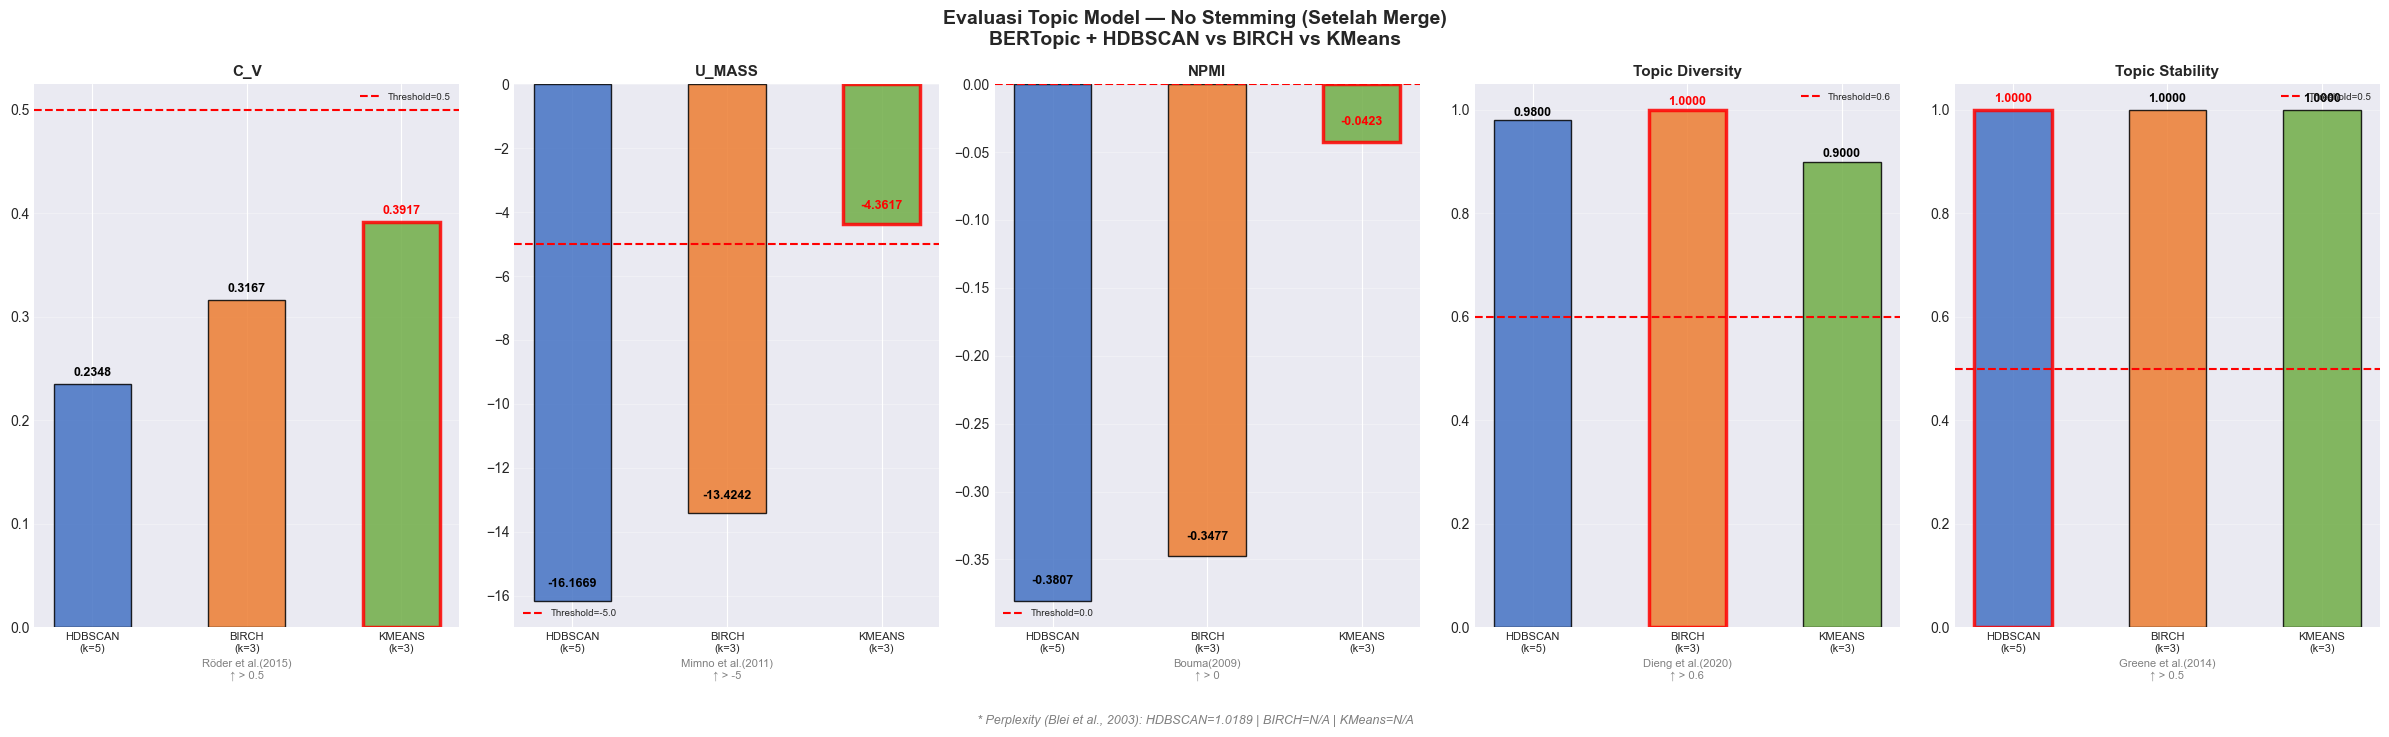

✓ Disimpan: evaluation_chart_no_stemming.png

🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING

  C_V terbaik        → KMEANS
  U_MASS terbaik     → KMEANS
  NPMI terbaik       → KMEANS
  Diversity terbaik  → BIRCH
  Stability terbaik  → HDBSCAN

  Voting:
    KMEANS     ███ (3 metrik)
    BIRCH      █ (1 metrik)
    HDBSCAN    █ (1 metrik)

  🏆 Model terbaik (No Stemming) → KMEANS

  ℹ️  Perplexity HDBSCAN : 1.0189
      BIRCH & KMeans    : N/A (tidak diikutkan voting)

✅ Evaluasi No Stemming selesai!


In [13]:
print("="*70)
print("TABEL PERBANDINGAN 3 MODEL — NO STEMMING")
print("="*70)

models = ["HDBSCAN", "BIRCH", "KMEANS"]

# ── Tabel ─────────────────────────────────────────────────────────
print(f"\n{'Model':<10} {'N Topik':>8} {'C_V':>8} {'U_MASS':>9} "
      f"{'NPMI':>8} {'Diversity':>10} {'Stability':>10} "
      f"{'Perplexity':>12}")
print("─"*80)

for name in models:
    s    = eval_results[name]
    perp = f"{s['perplexity']:.4f}" \
           if isinstance(s['perplexity'], float) else "N/A"
    print(f"{name:<10} {int(s['n_topics']):>8} "
          f"{s['c_v']:>8.4f} {s['u_mass']:>9.4f} "
          f"{s['npmi']:>8.4f} {s['diversity']:>10.4f} "
          f"{s['stability']:>10.4f} {perp:>12}")

print("─"*80)
print(f"{'Ideal':<10} {'─':>8} {'>0.5':>8} {'>-5.0':>9} "
      f"{'>0.0':>8} {'>0.6':>10} {'>0.5':>10} {'↓ min':>12}")

# Simpan CSV
rows = []
for name in models:
    s = eval_results[name]
    rows.append({
        'Model'      : name,
        'N_Topik'    : s['n_topics'],
        'C_V'        : s['c_v'],
        'U_MASS'     : s['u_mass'],
        'NPMI'       : s['npmi'],
        'Diversity'  : s['diversity'],
        'Stability'  : s['stability'],
        'Perplexity' : s['perplexity'],
        'Noise_Count': s['noise_count'],
        'Noise_Ratio': s['noise_ratio'],
    })

df_eval = pd.DataFrame(rows)
df_eval.to_csv('evaluation_no_stemming.csv', index=False)
print(f"\n✓ Disimpan: evaluation_no_stemming.csv")

# ── Visualisasi ───────────────────────────────────────────────────
metrics_plot = [
    ('c_v',       'C_V',             'Röder et al.(2015)\n↑ > 0.5',  0.5,  True),
    ('u_mass',    'U_MASS',          'Mimno et al.(2011)\n↑ > -5',   -5.0, True),
    ('npmi',      'NPMI',            'Bouma(2009)\n↑ > 0',            0.0,  True),
    ('diversity', 'Topic Diversity', 'Dieng et al.(2020)\n↑ > 0.6',  0.6,  True),
    ('stability', 'Topic Stability', 'Greene et al.(2014)\n↑ > 0.5', 0.5,  True),
]

colors = ['#4472C4', '#ED7D31', '#70AD47']
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle(
    'Evaluasi Topic Model — No Stemming (Setelah Merge)\n'
    'BERTopic + HDBSCAN vs BIRCH vs KMeans',
    fontsize=14, fontweight='bold'
)

for ax, (key, title, note, threshold, higher) in \
        zip(axes, metrics_plot):
    vals     = [eval_results[m][key] for m in models]
    bars     = ax.bar(models, vals, color=colors,
                      edgecolor='black', alpha=0.85, width=0.5)
    best_idx = int(np.argmax(vals)) if higher \
               else int(np.argmin(vals))

    ax.axhline(threshold, color='red', linestyle='--',
               linewidth=1.5, label=f'Threshold={threshold}')

    for i, (bar, val) in enumerate(zip(bars, vals)):
        if i == best_idx:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.5)
        offset = abs(max(vals)-min(vals))*0.03 \
                 if max(vals) != min(vals) else 0.01
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + offset,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='red' if i == best_idx else 'black'
        )

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [f"{m}\n(k={int(eval_results[m]['n_topics'])})"
         for m in models],
        fontsize=8
    )
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

perp_val = eval_results['HDBSCAN']['perplexity']
perp_str = f"{perp_val:.4f}" \
           if isinstance(perp_val, float) else "N/A"
fig.text(
    0.5, -0.04,
    f"* Perplexity (Blei et al., 2003): HDBSCAN={perp_str} | "
    f"BIRCH=N/A | KMeans=N/A",
    ha='center', fontsize=9, color='gray', style='italic'
)

plt.tight_layout()
plt.savefig('evaluation_chart_no_stemming.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: evaluation_chart_no_stemming.png")

# ── Rekomendasi ───────────────────────────────────────────────────
print(f"\n{'='*70}")
print("🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING")
print(f"{'='*70}")

best_cv   = max(eval_results, key=lambda m: eval_results[m]['c_v'])
best_um   = max(eval_results, key=lambda m: eval_results[m]['u_mass'])
best_npmi = max(eval_results, key=lambda m: eval_results[m]['npmi'])
best_div  = max(eval_results, key=lambda m: eval_results[m]['diversity'])
best_stab = max(eval_results, key=lambda m: eval_results[m]['stability'])

print(f"\n  C_V terbaik        → {best_cv}")
print(f"  U_MASS terbaik     → {best_um}")
print(f"  NPMI terbaik       → {best_npmi}")
print(f"  Diversity terbaik  → {best_div}")
print(f"  Stability terbaik  → {best_stab}")

votes  = Counter([best_cv, best_um, best_npmi, best_div, best_stab])
winner = votes.most_common(1)[0][0]

print(f"\n  Voting:")
for model, vote in votes.most_common():
    print(f"    {model:<10} {'█'*vote} ({vote} metrik)")

print(f"\n  🏆 Model terbaik (No Stemming) → {winner}")

perp_val = eval_results['HDBSCAN']['perplexity']
if perp_val is not None:
    print(f"\n  ℹ️  Perplexity HDBSCAN : {perp_val:.4f}")
    print(f"      BIRCH & KMeans    : N/A (tidak diikutkan voting)")

print(f"\n✅ Evaluasi No Stemming selesai!")

In [11]:
print("="*70)
print("INISIALISASI FUNGSI EVALUASI")
print("="*70)

# ================================================================
# KONVERSI BERTOPIC → FORMAT OCTIS
# ================================================================
def bertopic_to_octis(topic_model, top_n=10):
    """
    Konversi output BERTopic ke format OCTIS.
    Format: {"topics": [[kata1, kata2, ...], ...]}
    """
    info   = topic_model.get_topic_info()
    topics = []
    for _, row in info.iterrows():
        tid = row["Topic"]
        if tid == -1:
            continue
        words = topic_model.get_topic(tid)
        if words:
            topics.append([w for w, _ in words[:top_n]])
    return {"topics": topics}


# ================================================================
# 1. C_V — Gensim (Röder et al., 2015)
# ================================================================
def compute_cv(topic_model, texts_tokenized, dictionary, top_n=10):
    info         = topic_model.get_topic_info()
    topics_words = []
    for _, row in info.iterrows():
        tid = row["Topic"]
        if str(tid) == '-1':
            continue
        words = topic_model.get_topic(tid)
        tw    = [w for w, _ in (words or [])[:top_n*3]
                 if w in dictionary.token2id][:top_n]
        if len(tw) >= 2:
            topics_words.append(tw)
    if len(topics_words) < 2:
        print(f"    ⚠️  Topik valid < 2")
        return 0.0
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenized,
            dictionary=dictionary,
            coherence="c_v",
            topn=top_n
        )
        return round(cm.get_coherence(), 4)
    except Exception as e:
        print(f"    ⚠️  C_V error: {e}")
        return 0.0


# ================================================================
# 2. U_MASS — Gensim (Mimno et al., 2011)
# ================================================================
def compute_umass(topic_model, texts_tokenized, dictionary, top_n=10):
    info         = topic_model.get_topic_info()
    topics_words = []
    for _, row in info.iterrows():
        tid = row["Topic"]
        if str(tid) == '-1':
            continue
        words = topic_model.get_topic(tid)
        tw    = [w for w, _ in (words or [])[:top_n*3]
                 if w in dictionary.token2id][:top_n]
        if len(tw) >= 2:
            topics_words.append(tw)
    if len(topics_words) < 2:
        return 0.0
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenized,
            dictionary=dictionary,
            coherence="u_mass",
            topn=top_n
        )
        return round(cm.get_coherence(), 4)
    except Exception as e:
        print(f"    ⚠️  U_MASS error: {e}")
        return 0.0


# ================================================================
# 3. NPMI — OCTIS (Bouma, 2009)
# ================================================================
def compute_npmi(topic_model, texts_tokenized, top_n=10):
    try:
        octis_output = bertopic_to_octis(topic_model, top_n=top_n)
        npmi_metric  = Coherence(
            texts=texts_tokenized,
            measure='c_npmi',
            topk=top_n
        )
        return round(npmi_metric.score(octis_output), 4)
    except Exception as e:
        print(f"    ⚠️  NPMI error: {e}")
        return 0.0


# ================================================================
# 4. TOPIC DIVERSITY — OCTIS (Dieng et al., 2020)
# ================================================================
def compute_diversity(topic_model, top_n=10):
    try:
        octis_output     = bertopic_to_octis(topic_model, top_n=top_n)
        diversity_metric = TopicDiversity(topk=top_n)
        return round(diversity_metric.score(octis_output), 4)
    except Exception as e:
        print(f"    ⚠️  Diversity error: {e}")
        return 0.0


# ================================================================
# 5. TOPIC STABILITY — Jaccard (Greene et al., 2014)
# ================================================================
def jaccard_similarity(set1, set2):
    s1 = set(set1)
    s2 = set(set2)
    return len(s1 & s2) / len(s1 | s2) if len(s1 | s2) > 0 else 0.0


def compute_stability(topic_model, docs, embeddings,
                      umap_model, cluster_model,
                      vectorizer, ctfidf_model,
                      repr_model, calc_prob,
                      n_runs=3, top_n=10):
    """
    Jaccard Stability antar run.
    Referensi: Greene et al. (2014)
    Range: 0–1, ideal > 0.5
    """
    all_run_topics = []

    # ── Run 1: dari model existing ────────────────────────────────
    base = []
    for _, row in topic_model.get_topic_info().iterrows():
        if row['Topic'] == -1:
            continue
        w = topic_model.get_topic(row['Topic'])
        if w:
            base.append([x for x, _ in w[:top_n]])
    all_run_topics.append(base)
    print(f"     Run 1/{n_runs} ✓ ({len(base)} topik)")

    # ── Run 2 & 3: jalankan ulang ─────────────────────────────────
    for run in range(n_runs - 1):
        print(f"     Run {run+2}/{n_runs}...", end=" ")
        try:
            tm_temp = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=cluster_model,
                vectorizer_model=vectorizer,
                ctfidf_model=ctfidf_model,
                representation_model=repr_model,
                calculate_probabilities=calc_prob,
                verbose=False
            )
            tm_temp.fit_transform(docs, embeddings=embeddings)

            run_topics = []
            for _, row in tm_temp.get_topic_info().iterrows():
                if row['Topic'] == -1:
                    continue
                w = tm_temp.get_topic(row['Topic'])
                if w:
                    run_topics.append([x for x, _ in w[:top_n]])
            all_run_topics.append(run_topics)
            print(f"✓ ({len(run_topics)} topik)")
        except Exception as e:
            print(f"⚠️  {e}")
            continue

    # ── Hitung Jaccard antar semua pasangan run ───────────────────
    jaccard_scores = []
    for i in range(len(all_run_topics)):
        for j in range(i+1, len(all_run_topics)):
            ta_list = all_run_topics[i]
            tb_list = all_run_topics[j]
            min_len = min(len(ta_list), len(tb_list))
            if min_len == 0:
                continue

            used     = set()
            run_jacc = []
            for ta in ta_list[:min_len]:
                best_s, best_k = 0, -1
                for k, tb in enumerate(tb_list[:min_len]):
                    if k in used:
                        continue
                    s = jaccard_similarity(ta, tb)
                    if s > best_s:
                        best_s, best_k = s, k
                if best_k >= 0:
                    used.add(best_k)
                    run_jacc.append(best_s)
            if run_jacc:
                jaccard_scores.append(np.mean(run_jacc))

    return round(np.mean(jaccard_scores), 4) if jaccard_scores else 0.0


# ================================================================
# 6. PERPLEXITY — Numpy (Blei et al., 2003)
# ================================================================
def compute_perplexity(name, bertopic_results):
    """
    Hanya valid untuk HDBSCAN (calculate_probabilities=True)
    BIRCH & KMeans → N/A
    """
    try:
        probs = bertopic_results[name].get('probs', None)
        if probs is None:
            return None

        topics    = bertopic_results[name]['topics']
        valid_idx = [i for i, t in enumerate(topics) if t != -1]
        if len(valid_idx) == 0:
            return None

        pv       = np.array(probs)[valid_idx]
        if pv.ndim == 1:
            pv = pv.reshape(-1, 1)

        row_sums = np.clip(np.sum(pv, axis=1), 1e-10, None)
        log_perp = -1 * np.mean(np.log(row_sums))
        return round(float(np.exp(log_perp)), 4)

    except Exception as e:
        print(f"    ⚠️  Perplexity error: {e}")
        return None


print("✓ Fungsi C_V      → Gensim (Röder et al., 2015)")
print("✓ Fungsi U_MASS   → Gensim (Mimno et al., 2011)")
print("✓ Fungsi NPMI     → OCTIS  (Bouma, 2009)")
print("✓ Fungsi Diversity→ OCTIS  (Dieng et al., 2020)")
print("✓ Fungsi Stability→ Jaccard(Greene et al., 2014)")
print("✓ Fungsi Perplexity→ Numpy (Blei et al., 2003)")

INISIALISASI FUNGSI EVALUASI
✓ Fungsi C_V      → Gensim (Röder et al., 2015)
✓ Fungsi U_MASS   → Gensim (Mimno et al., 2011)
✓ Fungsi NPMI     → OCTIS  (Bouma, 2009)
✓ Fungsi Diversity→ OCTIS  (Dieng et al., 2020)
✓ Fungsi Stability→ Jaccard(Greene et al., 2014)
✓ Fungsi Perplexity→ Numpy (Blei et al., 2003)


In [12]:
print("="*70)
print("PERSIAPAN CORPUS")
print("="*70)

texts_tokenized = [str(doc).lower().split() for doc in docs]
dictionary      = corpora.Dictionary(texts_tokenized)
dictionary.filter_extremes(no_below=3, no_above=0.90)

print(f"✓ Total dokumen    : {len(texts_tokenized):,}")
print(f"✓ Dictionary size  : {len(dictionary):,} kata")
print(f"✓ Contoh token[0]  : {texts_tokenized[0][:8]}")

PERSIAPAN CORPUS
✓ Total dokumen    : 1,699
✓ Dictionary size  : 890 kata
✓ Contoh token[0]  : ['mau', 'masuk', 'beranda', 'selalu', 'loading']


In [13]:
# ================================================================
# ⚠️  Sesuaikan dengan nama variabel model di notebook kamu
# ================================================================
stability_cfg = {
    "HDBSCAN": {
        "cluster_model": hdbscan_model,
        "vectorizer"   : vectorizer_density,
        "repr_model"   : representation_model,
        "calc_prob"    : True,
    },
    "BIRCH": {
        "cluster_model": birch_model,
        "vectorizer"   : vectorizer_density,
        "repr_model"   : representation_model,
        "calc_prob"    : False,
    },
    "KMEANS": {
        "cluster_model": kmeans_model,
        "vectorizer"   : vectorizer_kmeans,
        "repr_model"   : None,
        "calc_prob"    : False,
    },
}

print("✓ Konfigurasi stability siap!")
print(f"\n  {'Model':<10} {'Cluster':<15} {'Calc Prob':>10}")
print("  " + "─"*37)
for name, cfg in stability_cfg.items():
    print(f"  {name:<10} "
          f"{type(cfg['cluster_model']).__name__:<15} "
          f"{str(cfg['calc_prob']):>10}")

✓ Konfigurasi stability siap!

  Model      Cluster          Calc Prob
  ─────────────────────────────────────
  HDBSCAN    HDBSCAN               True
  BIRCH      Birch                False
  KMEANS     KMeans               False


In [14]:
print("="*70)
print("EVALUASI TOPIC MODEL — NO STEMMING (SETELAH MERGE)")
print("Metrik: C_V | U_MASS | NPMI | Diversity | Stability | Perplexity")
print("="*70)

eval_results = {}

for name in ["HDBSCAN", "BIRCH", "KMEANS"]:

    print(f"\n{'─'*70}")
    print(f"📌 Evaluasi — {name}")
    print(f"{'─'*70}")

    tm      = bertopic_models[name]
    info    = tm.get_topic_info()
    n_topik = len(info[info['Topic'] != -1]) \
              if name == "HDBSCAN" else len(info)
    scores  = {}

    # Tampilkan topik aktif
    print(f"\n  📋 Jumlah topik: {n_topik}")
    print(f"  {'ID':>6} {'N Dok':>7}   Top Words")
    print(f"  {'─'*60}")
    for _, row in info.iterrows():
        if str(row['Topic']) == '-1':
            continue
        words = tm.get_topic(row['Topic'])
        top   = ", ".join([w for w, _ in words[:5]]) if words else "-"
        print(f"  #{row['Topic']:<5}  {row['Count']:>7,}   {top}")

    # ── 1. C_V ───────────────────────────────────────────────────
    print(f"\n  🔄 [1/6] C_V — Röder et al. (2015)")
    scores['c_v'] = compute_cv(
        tm, texts_tokenized, dictionary, top_n=10
    )
    print(f"         → {scores['c_v']:.4f}  "
          f"({'✅' if scores['c_v'] > 0.5 else '⚠️ '} ideal > 0.5)")

    # ── 2. U_MASS ─────────────────────────────────────────────────
    print(f"\n  🔄 [2/6] U_MASS — Mimno et al. (2011)")
    scores['u_mass'] = compute_umass(
        tm, texts_tokenized, dictionary, top_n=10
    )
    print(f"         → {scores['u_mass']:.4f}  "
          f"({'✅' if scores['u_mass'] > -5 else '⚠️ '} ideal > -5)")

    # ── 3. NPMI (OCTIS) ───────────────────────────────────────────
    print(f"\n  🔄 [3/6] NPMI — OCTIS (Bouma, 2009)")
    scores['npmi'] = compute_npmi(
        tm, texts_tokenized, top_n=10
    )
    print(f"         → {scores['npmi']:.4f}  "
          f"({'✅' if scores['npmi'] > 0 else '⚠️ '} ideal > 0)")

    # ── 4. Topic Diversity (OCTIS) ────────────────────────────────
    print(f"\n  🔄 [4/6] Topic Diversity — OCTIS (Dieng et al., 2020)")
    scores['diversity'] = compute_diversity(tm, top_n=10)
    print(f"         → {scores['diversity']:.4f}  "
          f"({'✅' if scores['diversity'] > 0.6 else '⚠️ '} ideal > 0.6)")

    # ── 5. Stability (Jaccard) ────────────────────────────────────
    print(f"\n  🔄 [5/6] Topic Stability — Jaccard (Greene et al., 2014)")
    cfg = stability_cfg[name]
    scores['stability'] = compute_stability(
        topic_model   = tm,
        docs          = docs,
        embeddings    = embeddings,
        umap_model    = umap_model,
        cluster_model = cfg['cluster_model'],
        vectorizer    = cfg['vectorizer'],
        ctfidf_model  = ctfidf_model,
        repr_model    = cfg['repr_model'],
        calc_prob     = cfg['calc_prob'],
        n_runs        = 3,
        top_n         = 10
    )
    print(f"         → {scores['stability']:.4f}  "
          f"({'✅' if scores['stability'] > 0.5 else '⚠️ '} ideal > 0.5)")

    # ── 6. Perplexity ─────────────────────────────────────────────
    print(f"\n  🔄 [6/6] Perplexity — Blei et al. (2003)")
    perp             = compute_perplexity(name, bertopic_results)
    scores['perplexity'] = perp
    if perp is not None:
        print(f"         → {perp:.4f}  (↓ makin baik)")
    else:
        print(f"         → N/A  (hanya HDBSCAN)")

    # ── Simpan scores ─────────────────────────────────────────────
    scores['n_topics']    = n_topik
    scores['noise_count'] = bertopic_results[name]['noise_count']
    scores['noise_ratio'] = bertopic_results[name]['noise_ratio']
    eval_results[name]    = scores

    # ── Ringkasan ─────────────────────────────────────────────────
    perp_str = f"{perp:.4f}" if perp is not None else "N/A"
    print(f"\n  📊 Ringkasan {name}:")
    print(f"  {'─'*45}")
    print(f"     N Topik    : {n_topik}")
    print(f"     C_V        : {scores['c_v']:.4f}   (↑ ideal > 0.5)")
    print(f"     U_MASS     : {scores['u_mass']:.4f}   (↑ mendekati 0)")
    print(f"     NPMI       : {scores['npmi']:.4f}   (↑ ideal > 0)")
    print(f"     Diversity  : {scores['diversity']:.4f}   (↑ ideal > 0.6)")
    print(f"     Stability  : {scores['stability']:.4f}   (↑ ideal > 0.5)")
    print(f"     Perplexity : {perp_str}")
    if scores['noise_count'] > 0:
        print(f"     Noise      : "
              f"{scores['noise_count']} ({scores['noise_ratio']:.1f}%)")

EVALUASI TOPIC MODEL — NO STEMMING (SETELAH MERGE)
Metrik: C_V | U_MASS | NPMI | Diversity | Stability | Perplexity

──────────────────────────────────────────────────────────────────────
📌 Evaluasi — HDBSCAN
──────────────────────────────────────────────────────────────────────

  📋 Jumlah topik: 5
      ID   N Dok   Top Words
  ────────────────────────────────────────────────────────────
  #0        1,111   sakit, rumah sakit, jadwal, perawat, ramah
  #1          293   mudah membantu, terbaik, rumit, bintang, menghemat waktu
  #2          196   ramah, cepat, profesional, bagus ramah, pelayanannya bagus
  #3           30   com, antri daftar, memudahkan memudahkan, programmer, membantu mempercepat
  #4           27   daftar vaksin, daftar bayar, positif, tolak, test

  🔄 [1/6] C_V — Röder et al. (2015)
         → 0.2348  (⚠️  ideal > 0.5)

  🔄 [2/6] U_MASS — Mimno et al. (2011)
         → -16.1669  (⚠️  ideal > -5)

  🔄 [3/6] NPMI — OCTIS (Bouma, 2009)
         → -0.3807  (⚠️  ideal > 

TABEL PERBANDINGAN 3 MODEL — NO STEMMING

Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
────────────────────────────────────────────────────────────────────────────────
HDBSCAN           5   0.2348  -16.1669  -0.3807     0.9800     1.0000       1.0189
BIRCH             3   0.3167  -13.4242  -0.3477     1.0000     1.0000          N/A
KMEANS            3   0.3917   -4.3617  -0.0423     0.9000     1.0000          N/A
────────────────────────────────────────────────────────────────────────────────
Ideal             ─     >0.5     >-5.0     >0.0       >0.6       >0.5        ↓ min

✓ Disimpan: evaluation_no_stemming.csv


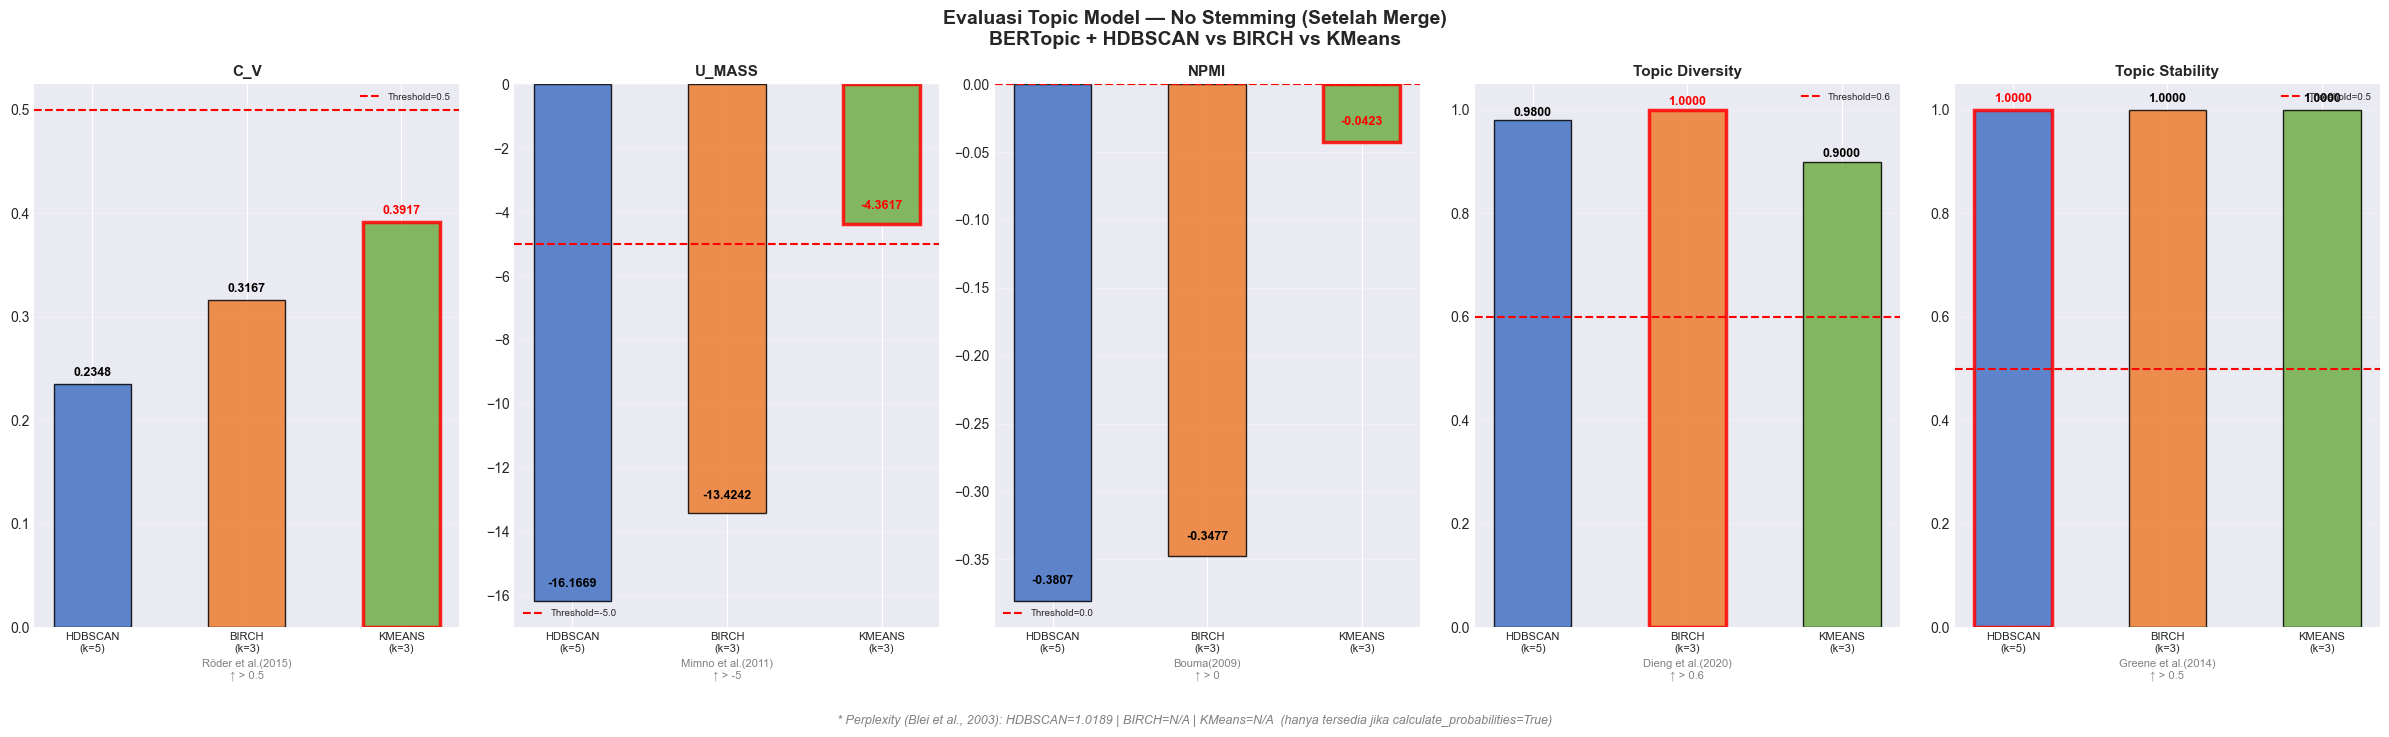

✓ Disimpan: evaluation_chart_no_stemming.png

🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING
(Voting dari 5 metrik: C_V, U_MASS, NPMI, Diversity, Stability)

  C_V terbaik        → KMEANS
  U_MASS terbaik     → KMEANS
  NPMI terbaik       → KMEANS
  Diversity terbaik  → BIRCH
  Stability terbaik  → HDBSCAN

  Voting:
    KMEANS     ███ (3 metrik)
    BIRCH      █ (1 metrik)
    HDBSCAN    █ (1 metrik)

  🏆 Model terbaik (No Stemming) → KMEANS

  ℹ️  Perplexity HDBSCAN : 1.0189
      BIRCH & KMeans    : N/A
      (tidak diikutkan voting)

✅ Evaluasi No Stemming selesai!


In [15]:
print("="*70)
print("TABEL PERBANDINGAN 3 MODEL — NO STEMMING")
print("="*70)

models = ["HDBSCAN", "BIRCH", "KMEANS"]

# ── Tabel ─────────────────────────────────────────────────────────
print(f"\n{'Model':<10} {'N Topik':>8} {'C_V':>8} {'U_MASS':>9} "
      f"{'NPMI':>8} {'Diversity':>10} {'Stability':>10} "
      f"{'Perplexity':>12}")
print("─"*80)

for name in models:
    s    = eval_results[name]
    perp = f"{s['perplexity']:.4f}" \
           if isinstance(s['perplexity'], float) else "N/A"
    print(f"{name:<10} {int(s['n_topics']):>8} "
          f"{s['c_v']:>8.4f} {s['u_mass']:>9.4f} "
          f"{s['npmi']:>8.4f} {s['diversity']:>10.4f} "
          f"{s['stability']:>10.4f} {perp:>12}")

print("─"*80)
print(f"{'Ideal':<10} {'─':>8} {'>0.5':>8} {'>-5.0':>9} "
      f"{'>0.0':>8} {'>0.6':>10} {'>0.5':>10} {'↓ min':>12}")

# Simpan CSV
rows = []
for name in models:
    s = eval_results[name]
    rows.append({
        'Model'      : name,
        'N_Topik'    : s['n_topics'],
        'C_V'        : s['c_v'],
        'U_MASS'     : s['u_mass'],
        'NPMI'       : s['npmi'],
        'Diversity'  : s['diversity'],
        'Stability'  : s['stability'],
        'Perplexity' : s['perplexity'],
        'Noise_Count': s['noise_count'],
        'Noise_Ratio': s['noise_ratio'],
    })

df_eval = pd.DataFrame(rows)
df_eval.to_csv('evaluation_no_stemming.csv', index=False)
print(f"\n✓ Disimpan: evaluation_no_stemming.csv")

# ── Visualisasi ───────────────────────────────────────────────────
metrics_plot = [
    ('c_v',       'C_V',             'Röder et al.(2015)\n↑ > 0.5',  0.5,  True),
    ('u_mass',    'U_MASS',          'Mimno et al.(2011)\n↑ > -5',   -5.0, True),
    ('npmi',      'NPMI',            'Bouma(2009)\n↑ > 0',            0.0,  True),
    ('diversity', 'Topic Diversity', 'Dieng et al.(2020)\n↑ > 0.6',  0.6,  True),
    ('stability', 'Topic Stability', 'Greene et al.(2014)\n↑ > 0.5', 0.5,  True),
]

colors = ['#4472C4', '#ED7D31', '#70AD47']
fig, axes = plt.subplots(1, 5, figsize=(24, 7))
fig.suptitle(
    'Evaluasi Topic Model — No Stemming (Setelah Merge)\n'
    'BERTopic + HDBSCAN vs BIRCH vs KMeans',
    fontsize=14, fontweight='bold'
)

for ax, (key, title, note, threshold, higher) in \
        zip(axes, metrics_plot):

    vals     = [eval_results[m][key] for m in models]
    bars     = ax.bar(models, vals, color=colors,
                      edgecolor='black', alpha=0.85, width=0.5)
    best_idx = int(np.argmax(vals)) if higher \
               else int(np.argmin(vals))

    ax.axhline(threshold, color='red', linestyle='--',
               linewidth=1.5, label=f'Threshold={threshold}')

    for i, (bar, val) in enumerate(zip(bars, vals)):
        if i == best_idx:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.5)
        offset = abs(max(vals)-min(vals))*0.03 \
                 if max(vals) != min(vals) else 0.01
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + offset,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='red' if i == best_idx else 'black'
        )

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [f"{m}\n(k={int(eval_results[m]['n_topics'])})"
         for m in models],
        fontsize=8
    )
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

# Catatan perplexity
perp_val = eval_results['HDBSCAN']['perplexity']
perp_str = f"{perp_val:.4f}" \
           if isinstance(perp_val, float) else "N/A"
fig.text(
    0.5, -0.04,
    f"* Perplexity (Blei et al., 2003): HDBSCAN={perp_str} | "
    f"BIRCH=N/A | KMeans=N/A  "
    f"(hanya tersedia jika calculate_probabilities=True)",
    ha='center', fontsize=9, color='gray', style='italic'
)

plt.tight_layout()
plt.savefig('evaluation_chart_no_stemming.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: evaluation_chart_no_stemming.png")

# ── Rekomendasi terbaik ───────────────────────────────────────────
print(f"\n{'='*70}")
print("🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING")
print(f"{'='*70}")
print("(Voting dari 5 metrik: C_V, U_MASS, NPMI, Diversity, Stability)")

best_cv   = max(eval_results, key=lambda m: eval_results[m]['c_v'])
best_um   = max(eval_results, key=lambda m: eval_results[m]['u_mass'])
best_npmi = max(eval_results, key=lambda m: eval_results[m]['npmi'])
best_div  = max(eval_results, key=lambda m: eval_results[m]['diversity'])
best_stab = max(eval_results, key=lambda m: eval_results[m]['stability'])

print(f"\n  C_V terbaik        → {best_cv}")
print(f"  U_MASS terbaik     → {best_um}")
print(f"  NPMI terbaik       → {best_npmi}")
print(f"  Diversity terbaik  → {best_div}")
print(f"  Stability terbaik  → {best_stab}")

votes  = Counter([best_cv, best_um, best_npmi, best_div, best_stab])
winner = votes.most_common(1)[0][0]

print(f"\n  Voting:")
for model, vote in votes.most_common():
    print(f"    {model:<10} {'█'*vote} ({vote} metrik)")

print(f"\n  🏆 Model terbaik (No Stemming) → {winner}")

perp_val = eval_results['HDBSCAN']['perplexity']
if perp_val is not None:
    print(f"\n  ℹ️  Perplexity HDBSCAN : {perp_val:.4f}")
    print(f"      BIRCH & KMeans    : N/A")
    print(f"      (tidak diikutkan voting)")

print(f"\n✅ Evaluasi No Stemming selesai!")

ULANG VERSI OKE

In [17]:
# ================================================================
# FUNGSI KONVERSI BERTOPIC → FORMAT OCTIS
# ================================================================
def bertopic_to_octis_output(topic_model, top_n=10):
    """
    Konversi hasil BERTopic ke format yang dikenali OCTIS.
    Format OCTIS: {"topics": [[kata1, kata2, ...], ...]}
    """
    info   = topic_model.get_topic_info()
    topics = []

    for _, row in info.iterrows():
        tid = row["Topic"]
        if tid == -1:
            continue
        words = topic_model.get_topic(tid)
        if words:
            topic_words = [w for w, _ in words[:top_n]]
            topics.append(topic_words)

    return {"topics": topics}


# ================================================================
# FUNGSI COHERENCE (GENSIM) — C_V & U_MASS
# ================================================================
def compute_coherence_gensim(topic_model, texts_tokenized, dictionary,
                              metric="c_v", top_n=10):
    info         = topic_model.get_topic_info()
    topics_words = []

    for _, row in info.iterrows():
        tid = row["Topic"]
        if str(tid) == '-1':
            continue
        words = topic_model.get_topic(tid)
        tw    = [w for w, _ in (words or [])[:top_n*3]
                 if w in dictionary.token2id][:top_n]
        if len(tw) >= 2:
            topics_words.append(tw)

    if len(topics_words) < 2:
        print(f"    ⚠️  Topik valid < 2, skip {metric}")
        return 0.0
    try:
        cm = CoherenceModel(
            topics=topics_words,
            texts=texts_tokenized,
            dictionary=dictionary,
            coherence=metric,
            topn=top_n
        )
        return round(cm.get_coherence(), 4)
    except Exception as e:
        print(f"    ⚠️  {metric} error: {e}")
        return 0.0


# ================================================================
# FUNGSI NPMI & TOPIC DIVERSITY (OCTIS)
# ================================================================
def compute_npmi_octis(topic_model, texts_tokenized, top_n=10):
    """Hitung NPMI menggunakan OCTIS."""
    try:
        octis_output = bertopic_to_octis_output(topic_model, top_n=top_n)
        npmi_metric  = Coherence(
            texts=texts_tokenized,
            measure='c_npmi',
            topk=top_n
        )
        score = npmi_metric.score(octis_output)
        return round(score, 4)
    except Exception as e:
        print(f"    ⚠️  NPMI OCTIS error: {e}")
        return 0.0


def compute_diversity_octis(topic_model, top_n=10):
    """Hitung Topic Diversity menggunakan OCTIS."""
    try:
        octis_output    = bertopic_to_octis_output(topic_model, top_n=top_n)
        diversity_metric = TopicDiversity(topk=top_n)
        score           = diversity_metric.score(octis_output)
        return round(score, 4)
    except Exception as e:
        print(f"    ⚠️  Topic Diversity error: {e}")
        return 0.0


# ================================================================
# FUNGSI TOPIC STABILITY (JACCARD)
# ================================================================
def jaccard_similarity(set1, set2):
    """Hitung Jaccard similarity antara dua set kata."""
    s1        = set(set1)
    s2        = set(set2)
    intersect = len(s1 & s2)
    union     = len(s1 | s2)
    return intersect / union if union > 0 else 0.0


def compute_stability(topic_model, docs, embeddings, umap_model,
                      cluster_model, vectorizer, ctfidf_model,
                      repr_model, calc_prob, n_runs=3, top_n=10):
    """
    Hitung Topic Stability dengan menjalankan model n_runs kali
    lalu menghitung rata-rata Jaccard similarity antar run.
    """
    all_run_topics = []

    # Run pertama = model yang sudah ada
    info_base  = topic_model.get_topic_info()
    base_topics = []
    for _, row in info_base.iterrows():
        if row['Topic'] == -1:
            continue
        words = topic_model.get_topic(row['Topic'])
        if words:
            base_topics.append([w for w, _ in words[:top_n]])
    all_run_topics.append(base_topics)

    # Run tambahan
    for run in range(n_runs - 1):
        try:
            tm_temp = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                hdbscan_model=cluster_model,
                vectorizer_model=vectorizer,
                ctfidf_model=ctfidf_model,
                representation_model=repr_model,
                calculate_probabilities=calc_prob,
                verbose=False
            )
            tm_temp.fit_transform(docs, embeddings=embeddings)

            run_topics = []
            for _, row in tm_temp.get_topic_info().iterrows():
                if row['Topic'] == -1:
                    continue
                words = tm_temp.get_topic(row['Topic'])
                if words:
                    run_topics.append([w for w, _ in words[:top_n]])
            all_run_topics.append(run_topics)
        except Exception as e:
            print(f"    ⚠️  Run {run+1} error: {e}")
            continue

    # Hitung Jaccard antar semua pasangan run
    jaccard_scores = []
    for i in range(len(all_run_topics)):
        for j in range(i+1, len(all_run_topics)):
            topics_a = all_run_topics[i]
            topics_b = all_run_topics[j]
            min_len  = min(len(topics_a), len(topics_b))

            if min_len == 0:
                continue

            # Greedy matching: pasangkan topik paling mirip
            used = set()
            run_jaccards = []
            for ta in topics_a[:min_len]:
                best_score = 0
                best_idx   = -1
                for k, tb in enumerate(topics_b[:min_len]):
                    if k in used:
                        continue
                    score = jaccard_similarity(ta, tb)
                    if score > best_score:
                        best_score = score
                        best_idx   = k
                if best_idx >= 0:
                    used.add(best_idx)
                    run_jaccards.append(best_score)

            if run_jaccards:
                jaccard_scores.append(np.mean(run_jaccards))

    return round(np.mean(jaccard_scores), 4) if jaccard_scores else 0.0


# ================================================================
# FUNGSI PERPLEXITY
# ================================================================
def compute_perplexity(topic_model, name):
    """
    Hitung perplexity dari probabilitas topik.
    Hanya valid jika calculate_probabilities=True (HDBSCAN).
    """
    try:
        # Ambil probabilitas dari hasil fit_transform
        probs = bertopic_results[name].get('probs', None)

        if probs is None:
            return None  # BIRCH & KMeans tidak punya probs

        # Filter noise (-1)
        topics    = bertopic_results[name]['topics']
        valid_idx = [i for i, t in enumerate(topics) if t != -1]

        if len(valid_idx) == 0:
            return None

        probs_valid = probs[valid_idx]

        # Hitung log perplexity
        row_sums = np.sum(probs_valid, axis=1)
        row_sums = np.clip(row_sums, 1e-10, None)  # hindari log(0)
        log_perp = -1 * np.mean(np.log(row_sums))
        perp     = np.exp(log_perp)
        return round(float(perp), 4)

    except Exception as e:
        print(f"    ⚠️  Perplexity error: {e}")
        return None


print("✓ Semua fungsi evaluasi siap!")

✓ Semua fungsi evaluasi siap!


In [18]:
print("="*70)
print("PERSIAPAN CORPUS UNTUK EVALUASI")
print("="*70)

# ── Tokenisasi untuk Gensim ───────────────────────────────────────
texts_tokenized = [str(doc).lower().split() for doc in docs]
dictionary      = corpora.Dictionary(texts_tokenized)
dictionary.filter_extremes(no_below=3, no_above=0.90)

print(f"✓ Total dokumen     : {len(texts_tokenized):,}")
print(f"✓ Dictionary size   : {len(dictionary):,} kata")
print(f"✓ Contoh tokens[0]  : {texts_tokenized[0][:10]}")

PERSIAPAN CORPUS UNTUK EVALUASI
✓ Total dokumen     : 1,699
✓ Dictionary size   : 890 kata
✓ Contoh tokens[0]  : ['mau', 'masuk', 'beranda', 'selalu', 'loading']


In [19]:
print("="*70)
print("EVALUASI TOPIK — NO STEMMING (SETELAH MERGE)")
print("Metrik: C_V, U_MASS, NPMI, Topic Diversity, Stability, Perplexity")
print("="*70)

# ── Konfigurasi cluster per model ─────────────────────────────────
# Sesuaikan dengan model yang sudah diinisialisasi di Cell 5 sebelumnya
cluster_configs_eval = {
    "HDBSCAN": {
        "cluster_model" : hdbscan_model,
        "vectorizer"    : vectorizer_density,
        "repr_model"    : representation_model,
        "calc_prob"     : True,
        "has_noise"     : True,
    },
    "BIRCH": {
        "cluster_model" : birch_model,
        "vectorizer"    : vectorizer_density,
        "repr_model"    : representation_model,
        "calc_prob"     : False,
        "has_noise"     : False,
    },
    "KMEANS": {
        "cluster_model" : kmeans_model,
        "vectorizer"    : vectorizer_kmeans,
        "repr_model"    : None,
        "calc_prob"     : False,
        "has_noise"     : False,
    },
}

eval_results = {}

for name, cfg in cluster_configs_eval.items():

    print(f"\n{'─'*70}")
    print(f"📌 Evaluasi — {name}")
    print(f"{'─'*70}")

    tm   = bertopic_models[name]
    info = tm.get_topic_info()
    n_topik = len(info[info['Topic'] != -1]) if cfg['has_noise'] \
              else len(info)

    print(f"\n  📋 Jumlah topik aktif: {n_topik}")
    scores = {}

    # ── 1. C_V ───────────────────────────────────────────────────
    print(f"\n  🔄 [1/6] Menghitung C_V (Gensim)...")
    scores['c_v'] = compute_coherence_gensim(
        tm, texts_tokenized, dictionary, metric="c_v", top_n=10
    )
    print(f"     → {scores['c_v']:.4f}")

    # ── 2. U_MASS ─────────────────────────────────────────────────
    print(f"\n  🔄 [2/6] Menghitung U_MASS (Gensim)...")
    scores['u_mass'] = compute_coherence_gensim(
        tm, texts_tokenized, dictionary, metric="u_mass", top_n=10
    )
    print(f"     → {scores['u_mass']:.4f}")

    # ── 3. NPMI (OCTIS) ───────────────────────────────────────────
    print(f"\n  🔄 [3/6] Menghitung NPMI (OCTIS)...")
    scores['npmi'] = compute_npmi_octis(
        tm, texts_tokenized, top_n=10
    )
    print(f"     → {scores['npmi']:.4f}")

    # ── 4. Topic Diversity (OCTIS) ────────────────────────────────
    print(f"\n  🔄 [4/6] Menghitung Topic Diversity (OCTIS)...")
    scores['diversity'] = compute_diversity_octis(tm, top_n=10)
    print(f"     → {scores['diversity']:.4f}")

    # ── 5. Topic Stability (Jaccard) ──────────────────────────────
    print(f"\n  🔄 [5/6] Menghitung Topic Stability (Jaccard, 3 runs)...")
    print(f"     (Proses ini memakan waktu beberapa menit...)")
    scores['stability'] = compute_stability(
        topic_model   = tm,
        docs          = docs,
        embeddings    = embeddings,
        umap_model    = umap_model,
        cluster_model = cfg['cluster_model'],
        vectorizer    = cfg['vectorizer'],
        ctfidf_model  = ctfidf_model,
        repr_model    = cfg['repr_model'],
        calc_prob     = cfg['calc_prob'],
        n_runs        = 3,
        top_n         = 10
    )
    print(f"     → {scores['stability']:.4f}")

    # ── 6. Perplexity ─────────────────────────────────────────────
    print(f"\n  🔄 [6/6] Menghitung Perplexity...")
    perp = compute_perplexity(tm, name)
    scores['perplexity'] = perp if perp is not None else "N/A"
    if perp is not None:
        print(f"     → {perp:.4f}")
    else:
        print(f"     → N/A (hanya tersedia untuk HDBSCAN)")

    # ── Noise info ────────────────────────────────────────────────
    scores['n_topics']    = n_topik
    scores['noise_count'] = bertopic_results[name]['noise_count']
    scores['noise_ratio'] = bertopic_results[name]['noise_ratio']

    eval_results[name] = scores

    # ── Ringkasan ─────────────────────────────────────────────────
    print(f"\n  📊 Ringkasan {name}:")
    print(f"  {'─'*45}")
    print(f"     N Topik      : {n_topik}")
    print(f"     C_V          : {scores['c_v']:.4f}   (↑ ideal > 0.5)")
    print(f"     U_MASS       : {scores['u_mass']:.4f}   (↑ mendekati 0)")
    print(f"     NPMI         : {scores['npmi']:.4f}   (↑ ideal > 0)")
    print(f"     Diversity    : {scores['diversity']:.4f}   (↑ ideal > 0.6)")
    print(f"     Stability    : {scores['stability']:.4f}   (↑ ideal > 0.5)")
    perp_str = f"{scores['perplexity']:.4f}   (↓ makin baik)" \
               if isinstance(scores['perplexity'], float) else "N/A"
    print(f"     Perplexity   : {perp_str}")
    print(f"     Noise        : {scores['noise_count']} ({scores['noise_ratio']:.1f}%)")

EVALUASI TOPIK — NO STEMMING (SETELAH MERGE)
Metrik: C_V, U_MASS, NPMI, Topic Diversity, Stability, Perplexity

──────────────────────────────────────────────────────────────────────
📌 Evaluasi — HDBSCAN
──────────────────────────────────────────────────────────────────────

  📋 Jumlah topik aktif: 5

  🔄 [1/6] Menghitung C_V (Gensim)...
     → 0.2348

  🔄 [2/6] Menghitung U_MASS (Gensim)...
     → -16.1669

  🔄 [3/6] Menghitung NPMI (OCTIS)...
     → -0.3807

  🔄 [4/6] Menghitung Topic Diversity (OCTIS)...
     → 0.9800

  🔄 [5/6] Menghitung Topic Stability (Jaccard, 3 runs)...
     (Proses ini memakan waktu beberapa menit...)
     → 1.0000

  🔄 [6/6] Menghitung Perplexity...
     → 1.0189

  📊 Ringkasan HDBSCAN:
  ─────────────────────────────────────────────
     N Topik      : 5
     C_V          : 0.2348   (↑ ideal > 0.5)
     U_MASS       : -16.1669   (↑ mendekati 0)
     NPMI         : -0.3807   (↑ ideal > 0)
     Diversity    : 0.9800   (↑ ideal > 0.6)
     Stability    : 1.000

TABEL PERBANDINGAN 3 MODEL — NO STEMMING

Model       N Topik      C_V    U_MASS     NPMI  Diversity  Stability   Perplexity
────────────────────────────────────────────────────────────────────────────────
HDBSCAN           5   0.2348  -16.1669  -0.3807     0.9800     1.0000       1.0189
BIRCH             3   0.3167  -13.4242  -0.3477     1.0000     1.0000          N/A
KMEANS            3   0.3917   -4.3617  -0.0423     0.9000     1.0000          N/A

✓ Disimpan: evaluation_no_stemming.csv


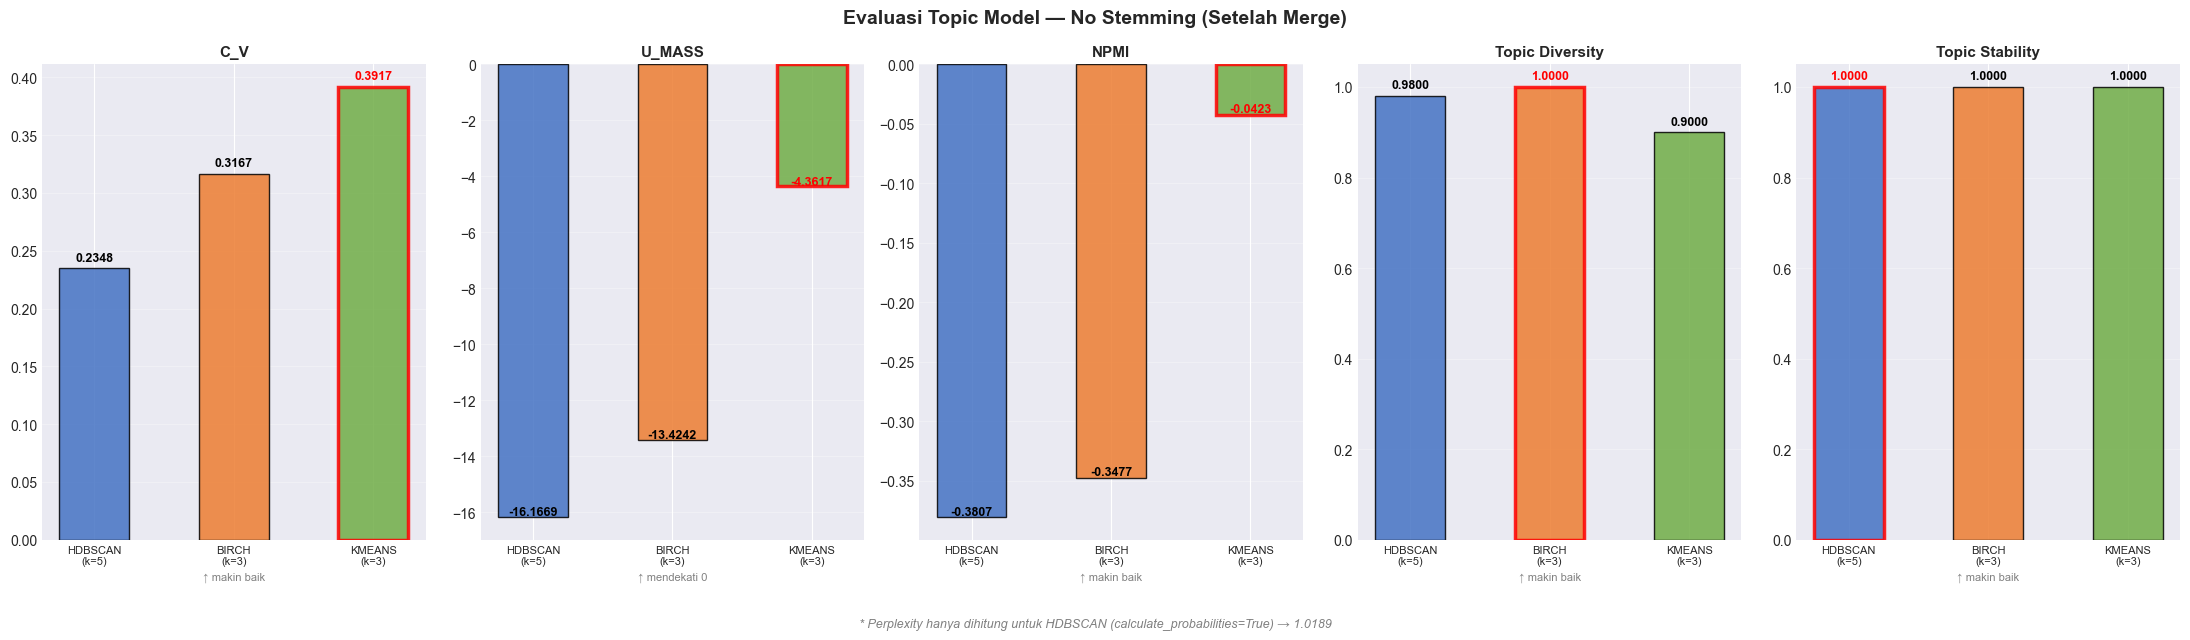

✓ Disimpan: evaluation_chart_no_stemming.png

🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING

  C_V terbaik        → KMEANS
  U_MASS terbaik     → KMEANS
  NPMI terbaik       → KMEANS
  Diversity terbaik  → BIRCH
  Stability terbaik  → HDBSCAN

  Voting:
    KMEANS     ███ (3 metrik)
    BIRCH      █ (1 metrik)
    HDBSCAN    █ (1 metrik)

  🏆 Model terbaik (No Stemming) → KMEANS


In [20]:
print("="*70)
print("TABEL PERBANDINGAN 3 MODEL — NO STEMMING")
print("="*70)

# ── Tabel ─────────────────────────────────────────────────────────
print(f"\n{'Model':<10} {'N Topik':>8} {'C_V':>8} {'U_MASS':>9} "
      f"{'NPMI':>8} {'Diversity':>10} {'Stability':>10} {'Perplexity':>12}")
print("─"*80)

for name in ["HDBSCAN", "BIRCH", "KMEANS"]:
    s    = eval_results[name]
    perp = f"{s['perplexity']:.4f}" if isinstance(s['perplexity'], float) \
           else "N/A"
    print(f"{name:<10} {int(s['n_topics']):>8} "
          f"{s['c_v']:>8.4f} {s['u_mass']:>9.4f} "
          f"{s['npmi']:>8.4f} {s['diversity']:>10.4f} "
          f"{s['stability']:>10.4f} {perp:>12}")

# Simpan ke CSV
rows = []
for name in ["HDBSCAN", "BIRCH", "KMEANS"]:
    s = eval_results[name]
    rows.append({
        'Model'      : name,
        'N_Topik'    : s['n_topics'],
        'C_V'        : s['c_v'],
        'U_MASS'     : s['u_mass'],
        'NPMI'       : s['npmi'],
        'Diversity'  : s['diversity'],
        'Stability'  : s['stability'],
        'Perplexity' : s['perplexity'] if isinstance(s['perplexity'], float) else None,
        'Noise_Count': s['noise_count'],
        'Noise_Ratio': s['noise_ratio'],
    })

df_eval = pd.DataFrame(rows)
df_eval.to_csv('evaluation_no_stemming.csv', index=False)
print(f"\n✓ Disimpan: evaluation_no_stemming.csv")

# ── Visualisasi ───────────────────────────────────────────────────
metrics_plot = [
    ('c_v',       'C_V',            '↑ makin baik',   True),
    ('u_mass',    'U_MASS',         '↑ mendekati 0',  True),
    ('npmi',      'NPMI',           '↑ makin baik',   True),
    ('diversity', 'Topic Diversity','↑ makin baik',   True),
    ('stability', 'Topic Stability','↑ makin baik',   True),
]

models = ["HDBSCAN", "BIRCH", "KMEANS"]
colors = ['#4472C4', '#ED7D31', '#70AD47']

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle(
    'Evaluasi Topic Model — No Stemming (Setelah Merge)',
    fontsize=14, fontweight='bold'
)

for ax, (key, title, note, higher_better) in zip(axes, metrics_plot):
    vals     = [eval_results[m][key] for m in models]
    bars     = ax.bar(models, vals, color=colors, edgecolor='black',
                      alpha=0.85, width=0.5)
    best_idx = int(np.argmax(vals)) if higher_better else int(np.argmin(vals))

    for i, (bar, val) in enumerate(zip(bars, vals)):
        # Highlight border merah untuk terbaik
        if i == best_idx:
            bar.set_edgecolor('red')
            bar.set_linewidth(2.5)
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + max(vals)*0.01,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='red' if i == best_idx else 'black'
        )

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(
        [f"{m}\n(k={int(eval_results[m]['n_topics'])})" for m in models],
        fontsize=8
    )
    ax.grid(axis='y', alpha=0.3)

# Tambah info perplexity HDBSCAN di bawah chart
perp_val = eval_results['HDBSCAN']['perplexity']
perp_str = f"{perp_val:.4f}" if isinstance(perp_val, float) else "N/A"
fig.text(
    0.5, -0.05,
    f"* Perplexity hanya dihitung untuk HDBSCAN (calculate_probabilities=True) → {perp_str}",
    ha='center', fontsize=9, color='gray', style='italic'
)

plt.tight_layout()
plt.savefig('evaluation_chart_no_stemming.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Disimpan: evaluation_chart_no_stemming.png")

# ── Rekomendasi model terbaik ─────────────────────────────────────
from collections import Counter

print(f"\n{'='*70}")
print("🏆 REKOMENDASI MODEL TERBAIK — NO STEMMING")
print(f"{'='*70}")

best_cv    = max(eval_results, key=lambda m: eval_results[m]['c_v'])
best_umass = max(eval_results, key=lambda m: eval_results[m]['u_mass'])
best_npmi  = max(eval_results, key=lambda m: eval_results[m]['npmi'])
best_div   = max(eval_results, key=lambda m: eval_results[m]['diversity'])
best_stab  = max(eval_results, key=lambda m: eval_results[m]['stability'])

print(f"\n  C_V terbaik        → {best_cv}")
print(f"  U_MASS terbaik     → {best_umass}")
print(f"  NPMI terbaik       → {best_npmi}")
print(f"  Diversity terbaik  → {best_div}")
print(f"  Stability terbaik  → {best_stab}")

votes  = Counter([best_cv, best_umass, best_npmi, best_div, best_stab])
winner = votes.most_common(1)[0][0]

print(f"\n  Voting:")
for model, vote in votes.most_common():
    bar = "█" * vote
    print(f"    {model:<10} {bar} ({vote} metrik)")

print(f"\n  🏆 Model terbaik (No Stemming) → {winner}")